Nombres y apellidos: Alfonso Íñiguez Cortés \
Correo: aic35@alu.ua.es \
Grupo: 3

# Grafos sobre la vida real 

Vamos a importar las librerías que vamos a necesitar a lo largo de esta práctica

In [27]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from IPython.display import Markdown

## 1. Commute Time Embedding

En las anteiores prácticas hemos estudiado como realizar caminos aleatorios sobre grafos y como usarlos para aprender embeddings de nodos con alogoritmos como `Node2Vec`. En esta sección vamos a estudiar otro enfoque diferente basado en **teoría espectral** : `Commute Time Embedding`

### 1.1 ¿Qué es el Commute Time Embedding?

Dado un grafo conexo dirigido $G = (V, E)$: el commute time embedding entre dos nodos `a` y `b` es el número que se espera de pasos que un camino aleatorio necesita recorrer desde `a` hasta `v` y de vuelta `a`. 

El **tiempo de golpe** son los pasos espetados para llegar desde `a` hasta `b`, definido por la siguiente expresión:
$$ CT(a,b) = H(a,b) + H(b, a) $$

Donde:
- $H(a,b)$: pasos para llegar desde `a` hasta `b` (y viceversa para $H(b,a)$)
- $CT(a,b)$: pasos totales de ida y vuelta

Esta forma de medición es más "rica" que la distancia mínima tradicional puesto que tienen en cuanta todos los caminos posibles y no  solo el más corto

**Relación con el laplaciano**
Podemos calcular este tiempo de desplazamiento si utilizamos la pseudoinversa del laplaciano del grafo:
$$ CT(u,v) = vol(G) * (Laa + Lbb - 2Lab) $$

Donde:
- L: psuedoinversa de Moore-Penrose (laplaciano)
- vol(G): representa el volumen del grafo -> suma de todos los grados. Viene dado por la fórmula:
$$ vol(G) = \sum_i(di) $$

Gracias a esta expresión, podemos relacionar directamente la estructura global del grafo con distancias entre nodos

### 1.2 ¿Por qué es útil el Commute Time?

Esta técnica posee varias ventajas notables e importantes:
- Tiene en cuenta la conectividad del grafo
- Está relacionada con `Random Walk` (caminos aleatorios)
- Permite representar nodos en espacios euclidianos
- Facilita detectar comumidades y grupos

Los nodos muy conectados entre sí van a tener un tiempo de desplazamiento pequeño, mientras que los poco conectados (aljeados) su tiempo de desplazamiento será mucho mayor

### 1.3 Laplaciano del grafo

Para poder calcular los embeddings, primero tenemos que construir el **laplaciano** de un grafo. Este viene definido por la siguiente fórmula:
$$ L = D - A $$

Donde:
- D: matriz diagonal de grafos
- A: matriz adyacencia
La matriz diagonal conotiene el grado de cada nodo: $D_(ii) = d_i$

El laplaciano cuenta con varias propiedades importantes:
- Es **simétrico**: sirve para utilizar algoritmos numéricamente estables (autovectores y autovalores)
- Es semidefinido positivo: todos los autovalores son >= a cero
- El menor autovalor **siempre** es cero:
$$ 0 = \gamma_i < \gamma_2 < ... < \gamma_n $$
El vector propio asociado a $\gamma_1$ es el vector cte
- El valor de Fielder: el segundo autovalor más pequeó ($\gamma_2$) mide qué tan conectado está el grafo:
-> Si $\gamma_2$ pequeño -> grafo tiene comunidades débiles \
-> Si $\gamma_2$ grande -> grafo muy conectado (comunidades fuertes)

### 1.4 Laplaciano -> Embeddings

El `Commmute Time Embedding` utiliza la descomposición espectral del laplaciano para constuir vectores asociados a cada nodo.

Representación de un nodo:
$$ z_i = (1/\sqrt(\gamma_2)*\alpha_2(i), 1/\sqrt(\gamma_3)*\alpha_3(i), ..., 1/\sqrt(\gamma_(k+1))*\alpha_(k+1)(i)) $$

Donde:
- $\alpha_j$ : autovectores
- $\gamma_j$ : autovalores
- $k$ : nº dimensiones

Al final, cada nodo queda representado por un vector numérico

##### Propiedad 
Distancia euclidiana entre embeddings aproxima el commute time:
$$ (|z_i - z_j|)^2 = CT(i, j) $$
Esta expresión significa que los nodos cercanos en el embedding estarán cerca a nivel estructural (del grafo)

### 1.5 Derivación paso a paso

**PASOS**
1. **Construir laplaciano**
$$ L = D - A $$

2. **Descomposición espectral**
Calculamos (del laplaciano):
- Autovalores ($\gamma_i$)
- Autovectores ($\alpha_i$)

3. **Seleccionar autovectores útiles**

Se elimina:
- $\alpha_1$ ya que corresponde con el autovalor 0 y no nos da información estructural 

Después:
- Se seleccionan los siguientes _K_ autovectores más importantes

4. **Escalado**
Cada autovector se divide por la expresión:
$$ 1/\sqrt{\gamma_j} $$
Esto hace que los autovalores pequeños tengan más importancia

5. **Construcción embedding**

Se crea la matriz:
$$ Z = [\gamma_2 | \gamma_3 |...| \gamma_(k+1)] $$
donde cada fila representa un nodo del grafo

### 1.3 Fragmento de código

Vamos a desglosar el siguente fragmento de código en bloques y vamos a explicar cada uno de ellos con el objetivo de entender el funcionamiento interno del `Commute Time Embedding`

In [3]:
import numpy as np
import networkx as nx
from scipy.linalg import eigh  # eigh for symmetric matrices (more stable than eig)

def commute_time_embedding(G, k):
    """
    Compute the Commute Time Embedding of graph G in k dimensions.

    Parameters
    ----------
    G : networkx.Graph
        An undirected connected graph.
    k : int
        Number of embedding dimensions (number of non-trivial eigenvectors to use).

    Returns
    -------
    Z : np.ndarray of shape (n_nodes, k)
        Embedding matrix. Row i is the embedding of node i.
        The squared Euclidean distance ||Z[i] - Z[j]||^2 equals the commute
        time CT(i, j).
    """
    # Step 1: Build the Laplacian
    L = nx.laplacian_matrix(G).toarray().astype(float)
    n = L.shape[0]

    # Step 2: Eigendecomposition — eigh returns eigenvalues in ascending order
    # We only need the first k+1 eigenpairs (0-indexed: 0 to k)
    eigenvalues, eigenvectors = eigh(L, subset_by_index=[0, k])
    # eigenvalues[j] = lambda_j, eigenvectors[:, j] = phi_j

    # Step 3: Skip lambda_0 = 0 (index 0); keep indices 1 to k
    # These correspond to lambda_2, ..., lambda_{k+1} in 1-indexed notation
    lam = eigenvalues[1:]        # shape (k,)
    Phi = eigenvectors[:, 1:]    # shape (n, k)

    # Safety check: all selected eigenvalues must be strictly positive
    if np.any(lam <= 1e-10):
        raise ValueError(
            "Graph appears to be disconnected or k is too large. "
            "All non-trivial eigenvalues must be strictly positive."
        )

    # Step 4: Scale each eigenvector by 1/sqrt(lambda_j)
    # Broadcasting: divide each column j of Phi by sqrt(lam[j])
    Z = Phi / np.sqrt(lam)   # shape (n, k)

    return Z

---

In [ ]:
# Step 1: Build the Laplacian
L = nx.laplacian_matrix(G).toarray().astype(float)
n = L.shape[0]

##### **Bloque 1** -> Construcción del laplaciano
---
Este bloque sirve para construir el laplaciano, que es el primer paso de este algoritmo

- **L**: calcula el laplaciano usando la fórmula: $L = D - A$
- **n**: obtenemos el número de filas de la matriz. Este valor representa el número de nodos del grafo (cada nodo es una fila)


In [ ]:
# Step 2: Eigendecomposition — eigh returns eigenvalues in ascending order
# We only need the first k+1 eigenpairs (0-indexed: 0 to k)
eigenvalues, eigenvectors = eigh(L, subset_by_index=[0, k])
# eigenvalues[j] = lambda_j, eigenvectors[:, j] = phi_j

##### **Bloque 2** -> Descomposicion espectral
---
En este bloque calculamos los autovalores y autovectores del laplaciano calculado en el primer bloque. Ambos se calculan con la función `eigh()`
- **eigenvalues**: autovalores 
- **eigenvectores**: autovectores

In [ ]:
# Step 3: Skip lambda_0 = 0 (index 0); keep indices 1 to k
# These correspond to lambda_2, ..., lambda_{k+1} in 1-indexed notation
lam = eigenvalues[1:]        # shape (k,)
Phi = eigenvectors[:, 1:]    # shape (n, k)

##### **Bloque 3** -> Eliminar autovector "trivial"
---
En este bloque eliminamos el primer autovector y autovalor (puesto que no aportan información estructural)
- **lam**: seleccionamos todos los autovalores menos el primero ```python [1:] ``` ya que el primero corresponde al vector constante (explicado en las anteriores secciones)
- **Phi**: seleccionamos todas las filas. En cuanto a las columnas, selccionamos desde la primera columna hasta el final, eliminando así el primer autovector

In [ ]:
# Safety check: all selected eigenvalues must be strictly positive
if np.any(lam <= 1e-10):
    raise ValueError(
        "Graph appears to be disconnected or k is too large. "
        "All non-trivial eigenvalues must be strictly positive."
    )

##### **_paso intermedio_** -> Comprobación seguridad
---
En este paso comprobamos:
- Grafo sea conexo 
- Autovalores sean válidos (para ser inválido: (0, cercano a 0))
Esta comprobación sirve para comprobar que el grafo no sea desconectado o existan problemas numéricos

In [ ]:
# Step 4: Scale each eigenvector by 1/sqrt(lambda_j)
# Broadcasting: divide each column j of Phi by sqrt(lam[j])
Z = Phi / np.sqrt(lam)   # shape (n, k)

##### **Bloque 4** -> Escalado de autovectores
---
En este bloque construimos el embedding final

- Calculamos $\sqrt(\gamma_j)$ para cada autovalor
- Dividiamos cada columna del autovector por el valor calculado (arriba) 

Luego:
- **Z**: matriz embedding (cada fila: nodo como vector)


### 1.7 Aplicación práctica

Ahora que sabemos como funciona el algoritmo a nivel de código, vamos a aplicarlo sobre un grafo sintético:

##### 1. Construccion y visualización del grafo

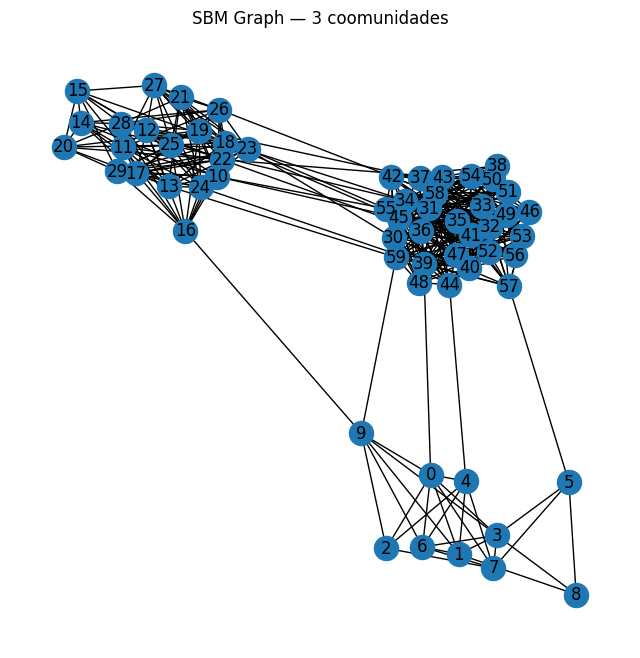

In [5]:
# -Construimos el grafo
G = nx.stochastic_block_model(
    [10, 20, 30],
    [
        [0.6,  0.02, 0.02],
        [0.02, 0.6,  0.02],
        [0.02, 0.02, 0.6 ]
    ],
    seed=99
)

# Vamos a visualizar el grafo
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=99)
plt.title("SBM Graph — 3 coomunidades")
nx.draw(G, pos, with_labels=True, node_size=300)
plt.show()

##### 2. Cálculo del embedding con K = 2

In [6]:
# Commute time embedding
k = 2  # Usamos 2 dimensiones para una visualización sencilla
Z = commute_time_embedding(G, k=k)

print(f"Embedding matrix shape: {Z.shape}")  # (60, 2)
print(f"Embedding of node 3: {Z[0]}")
print(f"Embedding of node 5: {Z[20]}")
print(f"Embedding of node 22: {Z[40]}")

Embedding matrix shape: (60, 2)
Embedding of node 3: [-0.37134038 -0.03214285]
Embedding of node 5: [ 0.13145233 -0.18676579]
Embedding of node 22: [0.05767251 0.12535408]


Traza paso a paso:

Veamos exactamente qué ocurre dentro de commute_time_embedding para este grafo concreto

1. Construir el Laplaciano:
`nx.laplacian_matrix(G).toarray()` produce una matriz 60×60. La entrada diagonal Lii=diL_

2. Descomposición espectral:
eigh(L, subset_by_index=[0, 2]) devuelve los 3 eigenpares más pequeños:

3.  3, 4 y 5 — Seleccionar, escalar y apilar.
```python
lam = [0.03, 0.04]           # los 2 eigenvalores no triviales más pequeños
Phi = [phi_2 | phi_3]        # shape (60, 2)
Z   = Phi / sqrt(lam)        # cada columna j dividida por sqrt(lambda_j)
```

La fila i de Z es la posición 2D del nodo i en el espacio de Commute Time. Los nodos de la misma comunidad tendrán posiciones cercanas; los de comunidades distintas,bposiciones alejadas

##### **Verificación de la propiedad del Commute Time**

Antes de visualizar, verificamos que el embedding es correcto comprobando que la distancia euclidiana al cuadrado entre dos embeddings aproxima bien el tiempo de conmutación real.
Para ello calculamos el CT de forma exacta usando la pseudoinversa del Laplaciano L+L^+
L+, y lo comparamos con el CT aproximado por el embedding (la distancia al cuadrado entre sus filas en ZZ
Z)

In [7]:
L = nx.laplacian_matrix(G).toarray().astype(float)
L_pinv = np.linalg.pinv(L)
vol_G  = 2 * G.number_of_edges()

def commute_time_exact(i, j, L_pinv, vol_G):
    return vol_G * (L_pinv[i, i] + L_pinv[j, j] - 2 * L_pinv[i, j])

pairs = [(0, 2), (0, 22), (0, 39)]
print(f"{'Par':>10}  {'CT exacto':>12}  {'CT embedding':>14}")
print("-" * 42)
for i, j in pairs:
    ct_exact = commute_time_exact(i, j, L_pinv, vol_G)
    ct_embed = np.sum((Z[i] - Z[j])**2)
    print(f"CT({i:2d},{j:2d})  {ct_exact:12.4f}  {ct_embed:14.4f}")

       Par     CT exacto    CT embedding
------------------------------------------
CT( 0, 2)      281.8155          0.0028
CT( 0,22)      358.1802          0.2474
CT( 0,39)      284.1807          0.1884


Elegimos tres pares representativos:

- CT(0, 2): dos nodos de la misma comunidad. Esperamos un CT pequeño (están bien conectados entre sí)
- CT(0, 22): nodos de comunidades distintas (comunidad 1 y 2). Esperamos un CT mayor
- CT(0, 39): nodos de comunidades distintas (comunidad 1 y 3). Esperamos un CT similar al anterior

### 1.8 Visualización de los embeddings

Por último, nos queda definir como represnetar los embeddings. Si usamos k= 2, no necesitasmos usar ninguna técnica de reducción (PCA, t-SNE): es una ventaja que nos ofrece el commute time embedding -> controlamos de forma directa las dimensiones de la salida

Vamos ahora a construir un grafo , obtener sus embeddings y visualizarlos a modo de ejemplo:

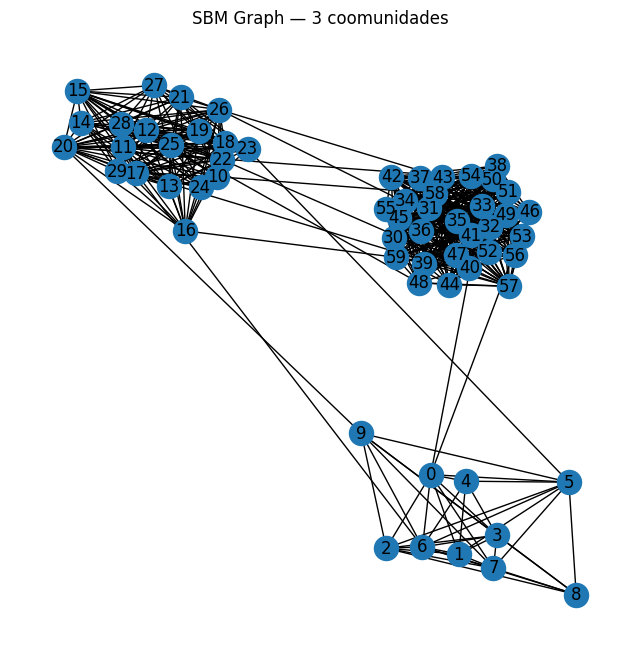

Embedding matrix shape: (60, 2)
Embedding of node 3: [-0.29706531  0.13124408]
Embedding of node 5: [-0.02415691 -0.1897904 ]
Embedding of node 22: [0.13566296 0.09045845]


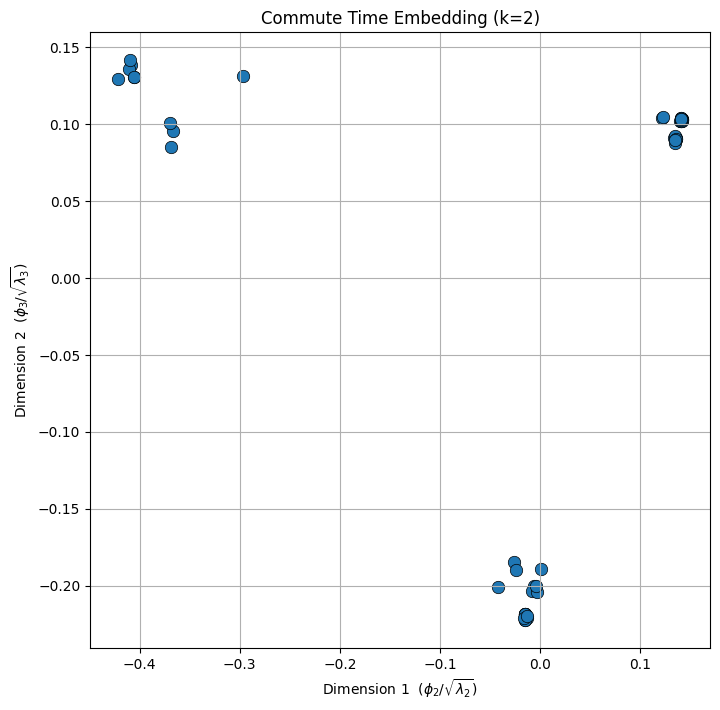

In [8]:
# CONSTRUCCIÓN
G = nx.stochastic_block_model(
    [10, 20, 30],
    [
        [0.8,  0.01, 0.01],
        [0.01, 0.8,  0.01],
        [0.01, 0.01, 0.8 ]
    ],
    seed=90
)

# Vamos a visualizar el grafo
plt.figure(figsize=(8, 8))
plt.title("SBM Graph — 3 coomunidades")
nx.draw(G, pos, with_labels=True, node_size=300)
plt.show()

# COMMUTE TIME EMBEDDING (2 dimensiones)

# Commute time embedding
k = 2  # Usamos 2 dimensiones para una visualización sencilla
Z = commute_time_embedding(G, k=k)

print(f"Embedding matrix shape: {Z.shape}")  # (60, 2)
print(f"Embedding of node 3: {Z[0]}")
print(f"Embedding of node 5: {Z[20]}")
print(f"Embedding of node 22: {Z[40]}")


# VISUALIZACIÓN
plt.figure(figsize=(8, 8))
plt.scatter(Z[:, 0], Z[:, 1], s=80, edgecolors='black', linewidths=0.5)
plt.title("Commute Time Embedding (k=2)")
plt.xlabel("Dimension 1  ($\\phi_2 / \\sqrt{\\lambda_2}$)")
plt.ylabel("Dimension 2  ($\\phi_3 / \\sqrt{\\lambda_3}$)")
plt.grid(True)
plt.show()

En el grafo que hemos creado, obeservamos como las conexiones en comunidades son fuertes pero hay pocas conexiones entre distintas comunidades. Debido a eso, observamos como los embeddings también nos aparecen en tres grupos visiblemente definidos. Esto ocurre porque los nodos de una misma comunidad tienen tiempos de desplazamiento cortos, mientras que entre  nodos de distintas comunidades ocurre lo contrario.  

Debido a esto, vamos a proponer un ejemplo donde los enlaces entre comunidades del grafo sean elevadas:

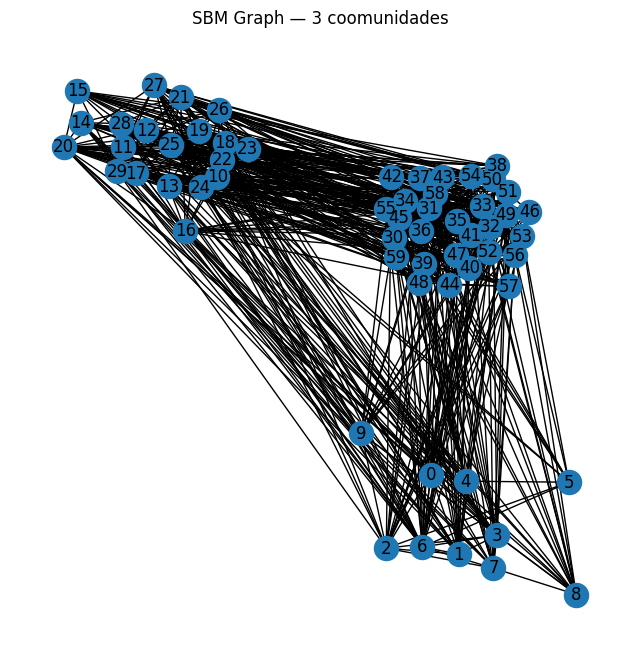

Embedding matrix shape: (60, 2)
Embedding of node 3: [ 0.0144097  -0.04039965]
Embedding of node 5: [ 0.01486411 -0.01448153]
Embedding of node 22: [ 0.00670104 -0.06290505]


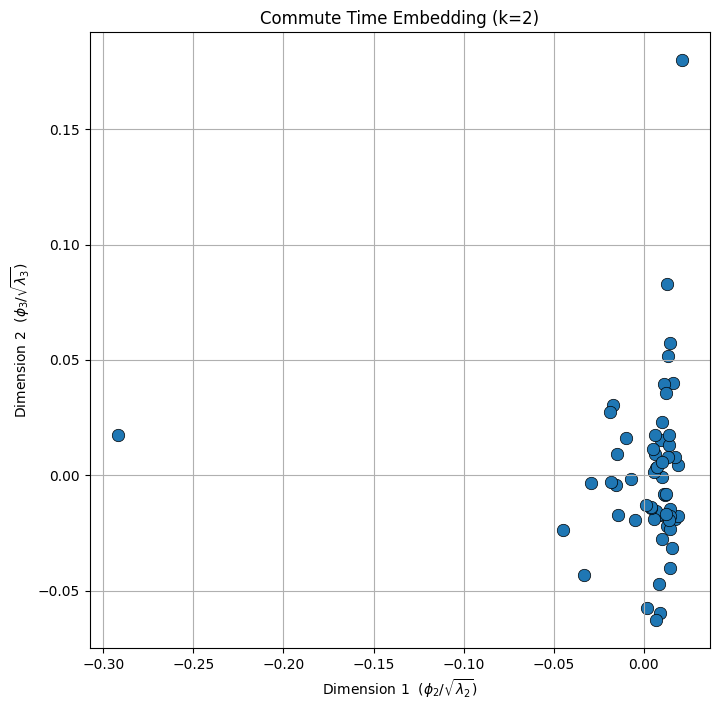

In [11]:
# CONSTRUCCIÓN
G = nx.stochastic_block_model(
    [10, 20, 30],
    [
        [0.5, 0.3, 0.3],
        [0.3, 0.5, 0.3],
        [0.3, 0.3, 0.5 ]
    ],
    seed=90
)

# Vamos a visualizar el grafo
plt.figure(figsize=(8, 8))
plt.title("SBM Graph — 3 coomunidades")
nx.draw(G, pos, with_labels=True, node_size=300)
plt.show()

# COMMUTE TIME EMBEDDING (2 dimensiones)

# Commute time embedding
k = 2  # Usamos 2 dimensiones para una visualización sencilla
Z = commute_time_embedding(G, k=k)

print(f"Embedding matrix shape: {Z.shape}")  # (60, 2)
print(f"Embedding of node 3: {Z[0]}")
print(f"Embedding of node 5: {Z[20]}")
print(f"Embedding of node 22: {Z[40]}")


# VISUALIZACIÓN
plt.figure(figsize=(8, 8))
plt.scatter(Z[:, 0], Z[:, 1], s=80, edgecolors='black', linewidths=0.5)
plt.title("Commute Time Embedding (k=2)")
plt.xlabel("Dimension 1  ($\\phi_2 / \\sqrt{\\lambda_2}$)")
plt.ylabel("Dimension 2  ($\\phi_3 / \\sqrt{\\lambda_3}$)")
plt.grid(True)
plt.show()

En el grafo que hemos creado, obeservamos como las conexiones entre comunidades son fuertes. Debido a eso, observamos como los embeddings pierden la estructura de comunidades. Esto ocurre porque todos los nodos, debido a la alta conectividad del grafo, tienen tiempos de desplazamiento alto. Este resultado se entiende mejor al mirar la gráfica obtenidad

Si tenemos incrustaciones de más de dimensiones (k>2), podemos usar los métodos `PCA` o `t-SNE` para poder visualizarlos correctamente. Vamos a ver un ejemplo aplicando el commute time embedding al grafo estocástico de alta conexión entre comunidades:

Forma del embedding de alta dimensión: (60, 16)


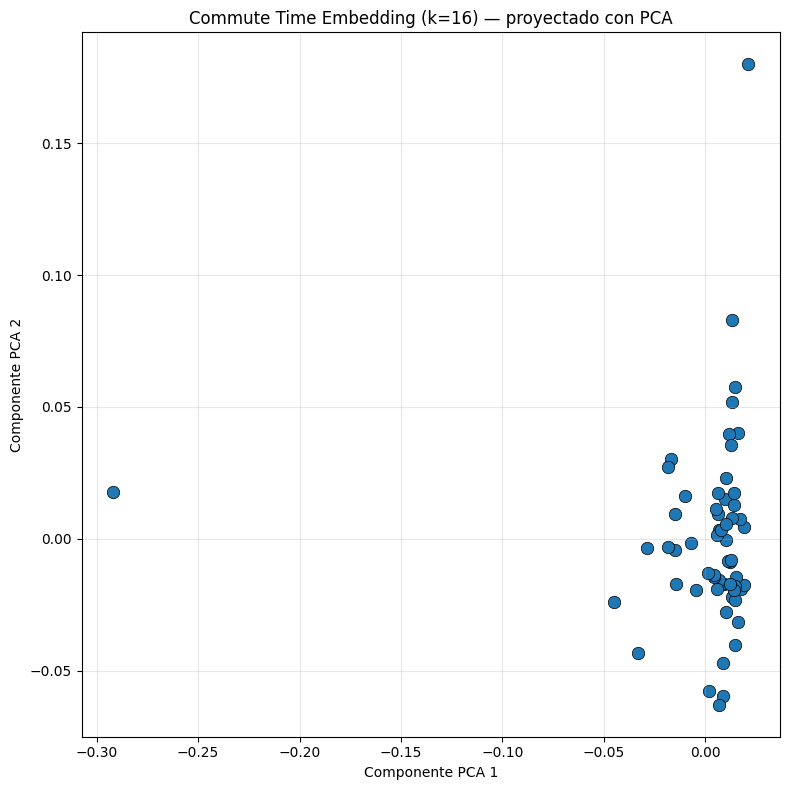

In [ ]:
from sklearn.decomposition import PCA

k_high = 16
Z_high = commute_time_embedding(G, k=k_high)
print(f"Forma del embedding de alta dimensión: {Z_high.shape}")  # (60, 16)

pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z_high)

plt.figure(figsize=(8, 8))
plt.scatter(Z_pca[:, 0], Z_pca[:, 1],
            s=80, edgecolors='black', linewidths=0.5)
plt.title(f"Commute Time Embedding (k={k_high}) — proyectado con PCA")
plt.xlabel("Componente PCA 1")
plt.ylabel("Componente PCA 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Vamos a proponer un ejemplo usando ahora el método de reducción `t-SNE`:

Forma del embedding de alta dimensión: (60, 16)


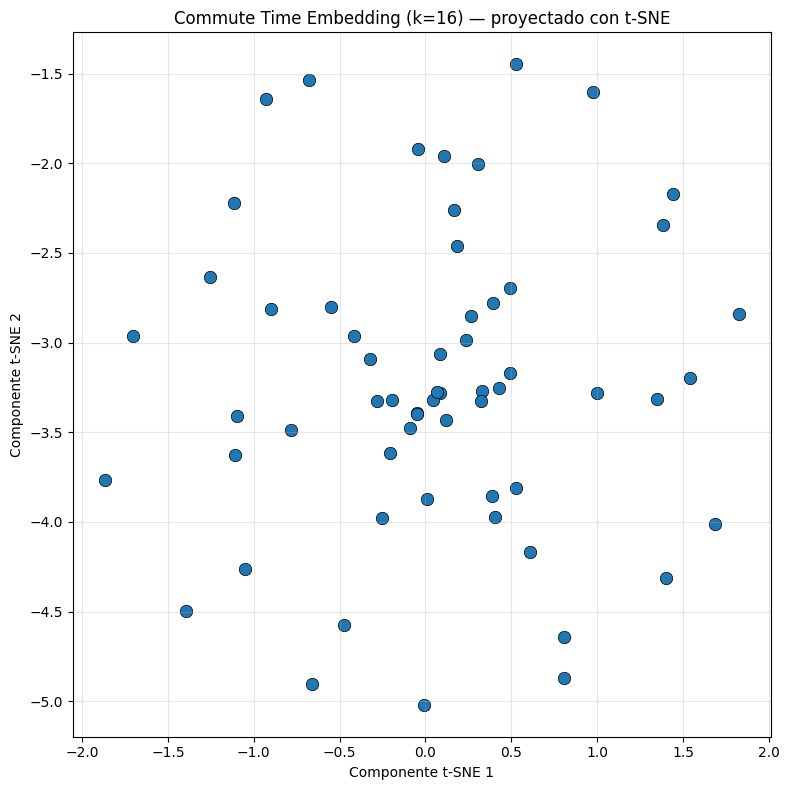

In [15]:
from sklearn.manifold import TSNE

k_high = 16
Z_high = commute_time_embedding(G, k=k_high)
print(f"Forma del embedding de alta dimensión: {Z_high.shape}")  # (60, 16)

tsne = TSNE(n_components=2)
Z_tsne = tsne.fit_transform(Z_high)

plt.figure(figsize=(8, 8))
plt.scatter(Z_tsne[:, 0], Z_tsne[:, 1],
            s=80, edgecolors='black', linewidths=0.5)
plt.title(f"Commute Time Embedding (k={k_high}) — proyectado con t-SNE")
plt.xlabel("Componente t-SNE 1")
plt.ylabel("Componente t-SNE 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Aproximación del Commute Time desde el Embedding

Como hemos estudiado en esta práctica, el `Commute Time Embedding` entre dos nodos puede calrulcarse usando la pseudoinversa. Sin embargo, tenemos otra forma de calcularlo directamente desde el embedding sin necesidad de esta pseudoinversa expresándolo como una suma de diferencias al cuadrado en el espacio espectral. La idea es que si ya hemos construido el embedding, no hace falta volver a la pseudoinversa: simplemente medimos cuánto se algen dos puntos en el espacio

## 2.1 El embedding de un nodo

Dado un grafo, la representación del nodo i en el espacio espectral es:

$$ e(i) = [\gamma_2(i)/\sqrt(\alpha_2), \gamma_3(i)/\sqrt(\alpha_3), \gamma_4(i)/\sqrt(\alpha_4)] $$

La razon de divididr por $\sqrt(\alpha_2)$ es estirar/comprimir cada eje del espacio para que las distancias reflejen con fidelidad el $CT$. Si no escaslamos, todos los ejes pesarían igual. Eso no es correcto puesto que los autovectores pequeños captan más información que los que que tienen valores más altos

-> 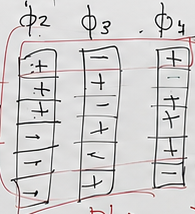

Mostramos el vector para los nodos 1 y 6 (leyendo directamente las filas de la tabla) y obtenemos:

- $$ e(1) = [\gamma_2(1)/\sqrt(\alpha_2), \gamma_3(1)/\sqrt(\alpha_3), \gamma_4(1)/\sqrt(\alpha_4)] $$

- $$ e(6) = [\gamma_2(6)/\sqrt(\alpha_6), \gamma_3(6)/\sqrt(\alpha_6), \gamma_4(6)/\sqrt(\alpha_6)] $$

Es decir:

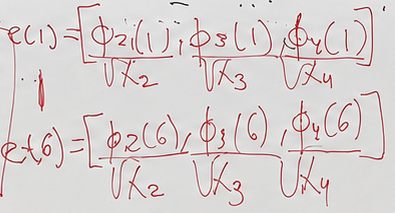

Si dos nodos tienen psociones (coordenadas) parecidas, significa que el grafo los "ve" de forma similar: vecinos parecidos, conexiones parecidas...

## 2.2 Fórmula expandida

El `Commute Time Embedding` entre i y j es la distancia al cuadrado entre sus embeddings escalada por $vol(G)$:

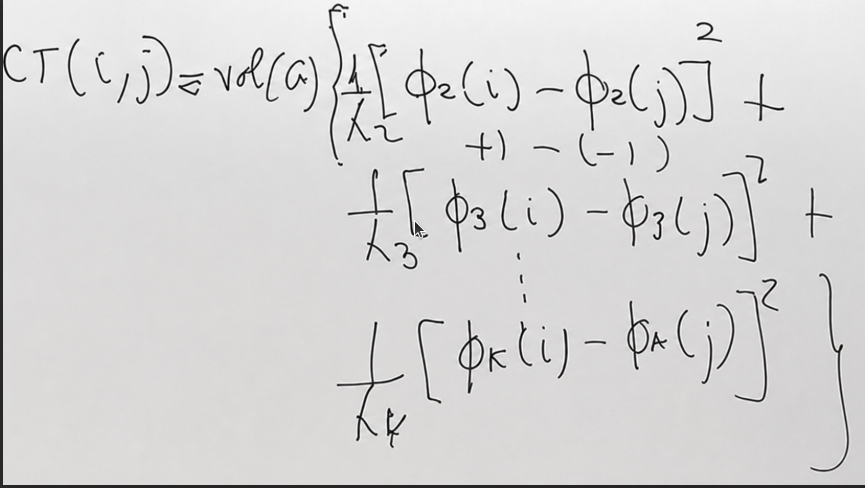

Cada término está ponderado por $1/\alpha_j$: esto significa que los autovectores aosicados a autovalores pequeños (básicamente son los que capturan la estructura global del grafo, comunidades) contribuyen más al commute time. Los autovectores grandes dan menos información puesto que captan variaciones locales

## 2.3 Volumen del grafo

El factor $vol(G)$ es la suma de todos los grafos de los nodos:

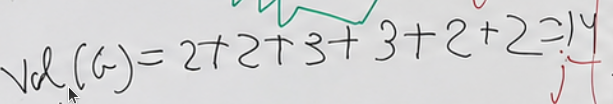

Este factor aparece porque el $CT$ está definido en términos de pasos de un camino aleatorio y el número de pasos esperado escala con el tamaño del grafo. Grafo más denso -> volumen mayor. Incluir $vol(G)$ en la fŕomula es lo que hace que las distancias en el embedding sean comparables entre grafos de distinto tamaño

## 2.4 Relación

Esa fórmula no es nueva a nivel conceptual: es la misma igualdad: $vol(G) * |z_i - z_j|²$. Lo que sí aporta es **claridad operativa**: deja ver exactamente de dónde sale cada parte del cálculo y cómo se conceta con las columnas de la tabla de autovectores

La aproximación viene del hecho de que usamos solo K autovectores en lugas de n-1. Con K pequeño: capturasmos estructura global más importabte (comunidades...) pero perdemos detalles. Es decir, que el error de aproximación sube conforme k crece hasta K = n-1

El coste de todo el proceso viene determinado por el cálculo de esos k autovectores: que es de coste:

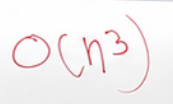

# Ejercicios

## Ejercicio 2

Funciones auxiliares :

In [34]:
# FUNCIONES AUXILIARES
#⨪--------------------#

# FUNCIÓN PCA
def pca(embeddings):
    """
    Función que reduce las dimensiones de embeddings (por defecto a 2) aplicando la técnica de reducción PCA

    Args
    -----
        - embeddings: Vectores de alta dimensión que se quieren reducir

    Returns
    -------
        - embeddings_pca: Embeddings reducidos a 2 dimensiones

    """
    pca = PCA(n_components=2)                                             
    embeddings_pca = pca.fit_transform(embeddings)   

    return embeddings_pca, "PCA"

# FUNCIÓN T-SNE
def t_sne(embeddings):
    """
    Función que reduce las dimensiones de embeddings (por defecto a 2) aplicando la técnica de reducción t-SNE

    Args
    -----
        - embeddings: Vectores de alta dimensión que se quieren reducir

    Returns
    -------
        - embeddings_sne: Embeddings reducidos a 2 dimensiones

    """
    tsne = TSNE(n_components=2, perplexity=25, random_state=42)                        
    embeddings_tsne = tsne.fit_transform(embeddings)    

    return embeddings_tsne, "t-SNE"


# ALGORITMO COMMUTE TIME EMBEDDING -> Implementado anteriormente (commute_time_embedding(G, k))

def properties(embeddings) -> None:
    """
    Función que muestra por pantalla propiedades de embeddings
    
    """

    display(Markdown(f'### **Información de los embeddings del grafo**'))
    print(f"Embeddings shape: {embeddings.shape}") 
    print(f"Embeddings mean: {embeddings.mean()}") 
    print(f"Embeddings max: {embeddings.max()}") 
    print(f"Embeddings min: {embeddings.min()}") 


def cte(g, k):
    """
    Función que aplica el Commute Time Embedding a un grafo dado, obtiene los embeddings
    del grafo y luego aplica a estos una técnica de reducción de dimensiones (PCA o t-SNE
    -> se elige aleatoriamente)

    Args
    -----
        - g: Grafo al que se aplica el Commute Time Embedding
        - k: Número de dimensiones del embedding

    Returns
    -------
        - embeddings_2d: Embeddings con las dimensiones reducidas (a 2D por defecto)
        - name: Nombre de la técnica de reducción que se haya usado
        - embeddings: Embeddings originales (sin reducción)

    """
    embeddings = commute_time_embedding(g, k)

    if k <= 2:
        return embeddings, "directo", embeddings

    # APLICAMOS REDUCCIÓN A LOS EMBEDDINGS OBTENIDOS
    method = np.random.choice([pca, t_sne])
    embeddings_2d, name = method(embeddings)

    return embeddings_2d, name, embeddings
    

# FUNCIÓN DE VISUALIZACIÓN
def visualization(g, k) -> None:
    """
    Esta función muestra de forma visual un grafo y sus embeddings después de aplicar
    Commute Time Embedding. El objetivo es mostrar en una figura dos visualizaciones:
    en la primera mostramos el grafo original y en la segunda los embeddings del mismo.
    Además, debajo se imprimen por pantalla los datos obtenidos después de aplicar CTE
    al grafo. Para k=2 se visualiza directamente; para k>2 se aplica PCA o t-SNE
    (elección aleatoria).

    Args
    -----
        - g: Tipo de grafo sobre el que queremos aplicar el Commute Time Embedding
        - k: Número de dimensiones del embedding

    """

    # ERDOS-RÉNYI
    if g == "e_r":

        fig, ax = plt.subplots(1,2, figsize=(17,7))
        e_r = nx.erdos_renyi_graph(30, 0.25, seed=50)
        ax[0].set_title('Grafo aleatorio (Modelo Erdos-Rényi)')
        posiciones = nx.spring_layout(e_r, seed=18)
        nx.draw_networkx_nodes(e_r, posiciones, node_color='black', node_size=250, ax=ax[0])
        nx.draw_networkx_edges(e_r, posiciones, edge_color='red', style='-.', ax=ax[0])
        ax[0].axis('off')

        embeddings_2d, name, embeddings = cte(e_r, k)

        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')
        ax[1].set_title(f'Commute Time Embedding ({name})')
        plt.show()

        properties(embeddings)

    # BARABÁSI-ALBERT
    if g == "b_a":

        fig, ax = plt.subplots(1,2, figsize=(17,7))
        b_a = nx.barabasi_albert_graph(30, 4, seed=50)
        ax[0].set_title('Grafo aleatorio (Modelo Barabási-Albert)')
        posiciones = nx.spring_layout(b_a, seed=18)
        nx.draw_networkx_nodes(b_a, posiciones, node_color='red', node_size=250, ax=ax[0])
        nx.draw_networkx_edges(b_a, posiciones, edge_color='black', style='--', ax=ax[0])
        ax[0].axis('off')

        embeddings_2d, name, embeddings = cte(b_a, k)

        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')
        ax[1].set_title(f'Commute Time Embedding ({name})')
        plt.show()

        properties(embeddings)

    # WATTS-STROGATZ
    if g == "w_s":

        fig, ax = plt.subplots(1,2, figsize=(17,7))
        w_s = nx.watts_strogatz_graph(30, 4, 0.5, seed=50)
        ax[0].set_title('Grafo aleatorio (Modelo Watts-Strogatz)')
        posiciones = nx.spring_layout(w_s, seed=18)
        nx.draw_networkx_nodes(w_s, posiciones, node_color='yellow', node_size=250, ax=ax[0])
        nx.draw_networkx_edges(w_s, posiciones, edge_color='green', style='--', ax=ax[0])
        ax[0].axis('off')

        embeddings_2d, name, embeddings = cte(w_s, k)

        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')
        ax[1].set_title(f'Commute Time Embedding ({name})')
        plt.show()

        properties(embeddings)

    # ÁRBOL
    if g == "r_t":

        fig, ax = plt.subplots(1,2, figsize=(17,7))
        r_t = nx.random_labeled_tree(30, seed=50)
        ax[0].set_title('Grafo aleatorio de árbol')
        posiciones = nx.spring_layout(r_t, seed=18)
        nx.draw_networkx_nodes(r_t, posiciones, node_color='skyblue', node_size=250, ax=ax[0])
        nx.draw_networkx_edges(r_t, posiciones, edge_color='orange', style=':', ax=ax[0])
        ax[0].axis('off')

        embeddings_2d, name, embeddings = cte(r_t, k)

        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')
        ax[1].set_title(f'Commute Time Embedding ({name})')
        plt.show()

        properties(embeddings)

    # SMB
    if g == "SMB":
        sizes = [10, 10, 10, 10]
        baja = [[0.8, 0.02, 0.02, 0.02],[0.02, 0.8, 0.02, 0.02],[0.02, 0.02, 0.8, 0.02],[0.02, 0.02, 0.02, 0.8]]
        alta = [[0.8, 0.4, 0.4, 0.4],[0.4, 0.8, 0.4, 0.4],[0.4, 0.4, 0.8, 0.4],[0.4, 0.4, 0.4, 0.8]]
        seed = 96

        G1 = nx.stochastic_block_model(sizes, baja, seed=seed)
        G2 = nx.stochastic_block_model(sizes, alta, seed=seed)

        emb_baja, name_baja, embeddings_baja = cte(G1, k)
        emb_alta, name_alta, embeddings_alta = cte(G2, k)

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        pos = nx.spring_layout(G1, seed=seed)

        axes[0,0].set_title('SBM - Baja conexión entre bloques')
        nx.draw_networkx_nodes(G1, pos, node_size=300, node_color='green', ax=axes[0,0])
        nx.draw_networkx_edges(G1, pos, edge_color='black', style='-.', ax=axes[0,0])
        axes[0,0].axis('off')
        

        axes[0,1].scatter(emb_baja[:,0], emb_baja[:,1], color='black')
        axes[0,1].set_title(f'Commute Time Embedding ({name_baja})')

        axes[1,0].set_title('SBM - Alta conexión entre bloques')
        nx.draw_networkx_nodes(G2, pos, node_size=300, node_color='yellow', ax=axes[1,0])
        nx.draw_networkx_edges(G2, pos, edge_color='black', style=':', ax=axes[1,0])
        axes[1,0].axis('off')

        axes[1,1].scatter(emb_alta[:,0], emb_alta[:,1], color='black')
        axes[1,1].set_title(f'Commute Time Embedding ({name_alta})')

        plt.show()

        display(Markdown('---'))
        properties(embeddings_baja)
        display(Markdown('---'))
        properties(embeddings_alta)

## **APLICAMOS COMMUTE TIME EMBEDDING A LOS GRAFOS SINTÉTCIOS**

**ERDOS-RÉNYI**

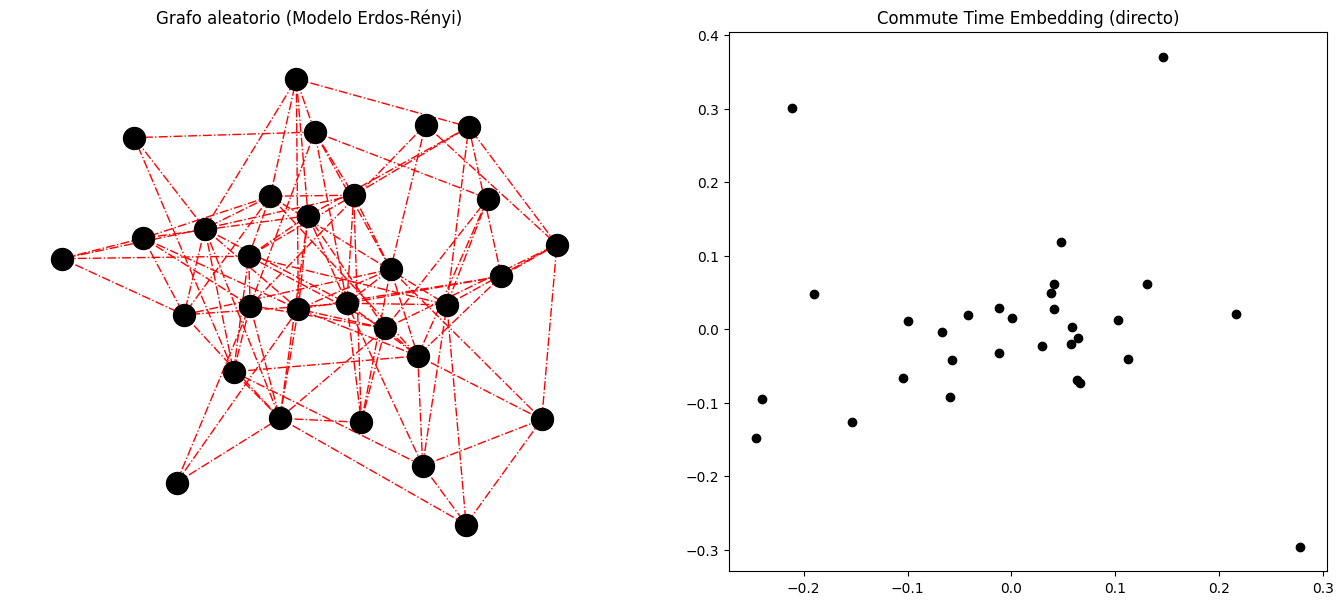

### **Información de los embeddings del grafo**

Embeddings shape: (30, 2)
Embeddings mean: -2.7119510341104083e-17
Embeddings max: 0.3703694396710584
Embeddings min: -0.29621124006689886


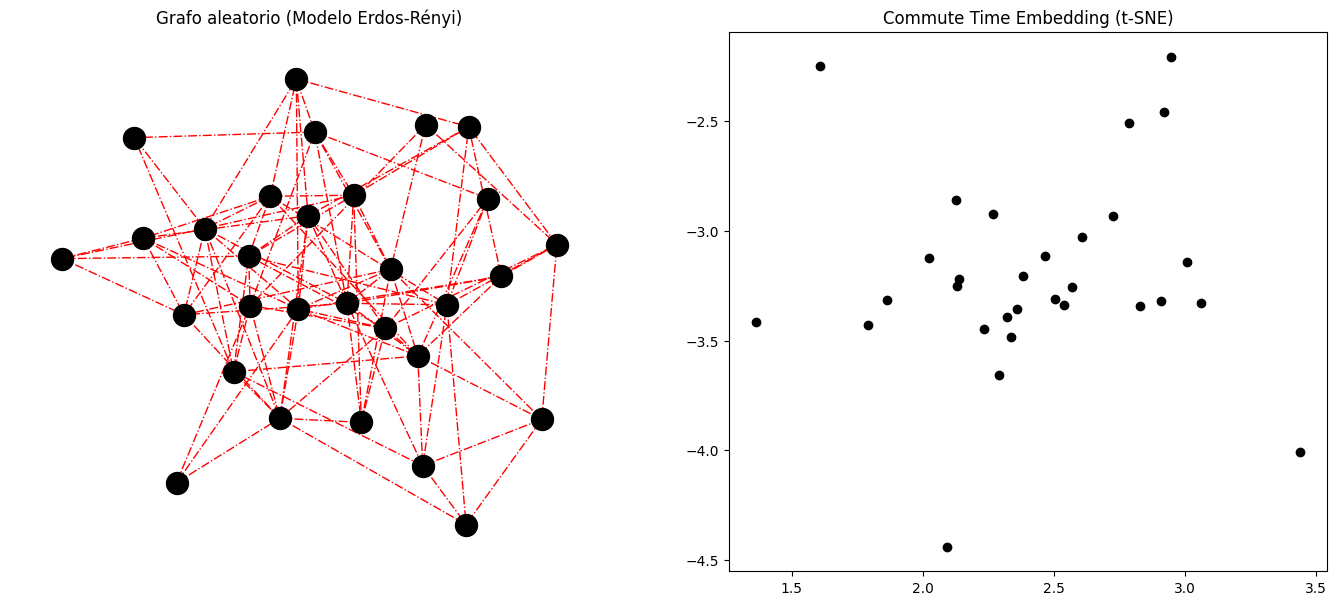

### **Información de los embeddings del grafo**

Embeddings shape: (30, 5)
Embeddings mean: 3.7007434154171884e-18
Embeddings max: 0.3977022009603608
Embeddings min: -0.2962112400668983


In [35]:
visualization(g = "e_r", k=2)
visualization(g = "e_r", k=5)

**BARABASI-ALBERT**

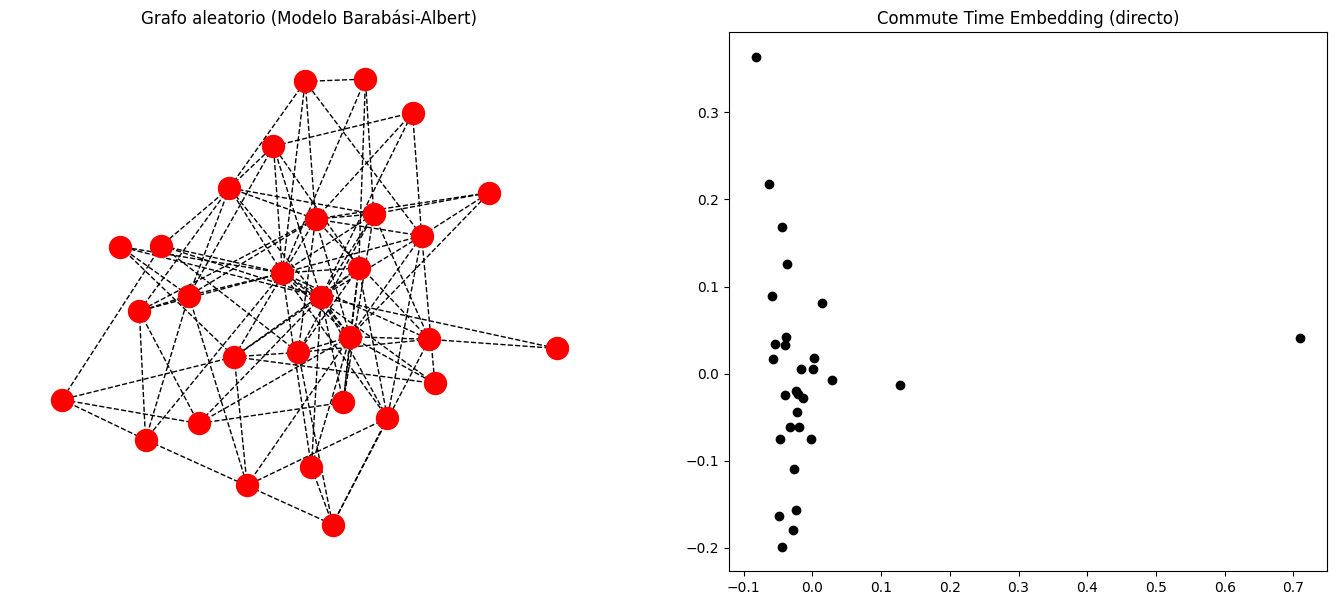

### **Información de los embeddings del grafo**

Embeddings shape: (30, 2)
Embeddings mean: -2.590520390792032e-17
Embeddings max: 0.7099533946961765
Embeddings min: -0.19890362741078224


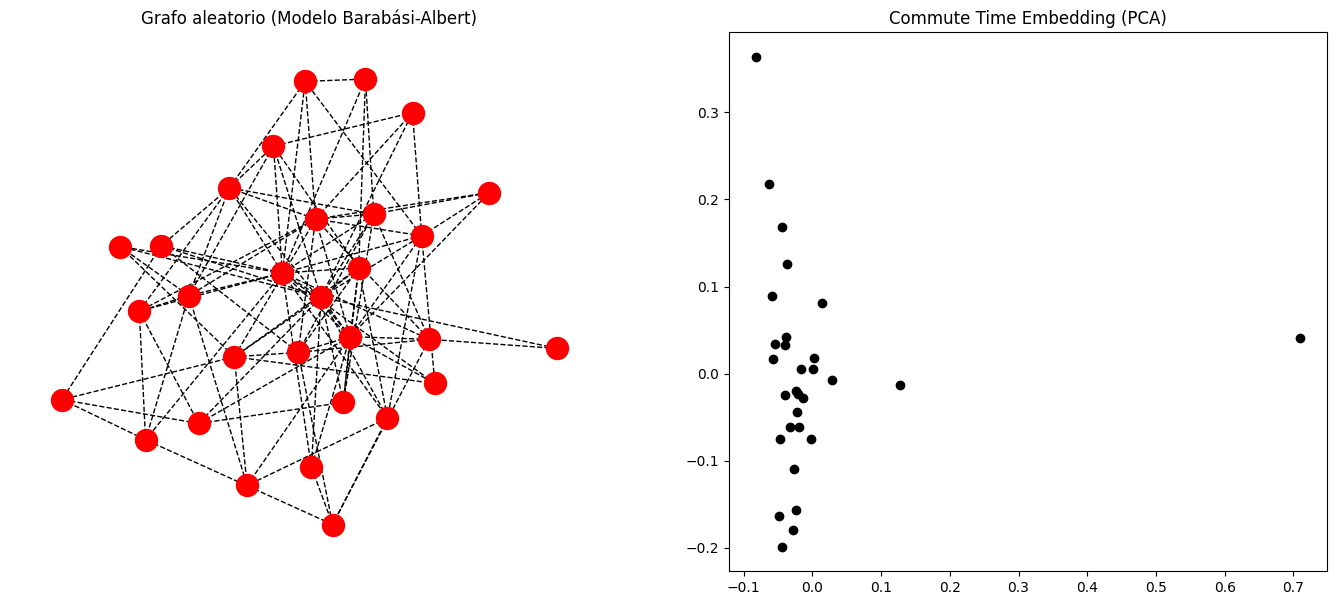

### **Información de los embeddings del grafo**

Embeddings shape: (30, 5)
Embeddings mean: -1.5358085173981332e-17
Embeddings max: 0.7099533946961768
Embeddings min: -0.23176606533960156


In [36]:
visualization(g = "b_a", k=2)
visualization(g = "b_a", k=5)

**WATTS-STROGATZ**

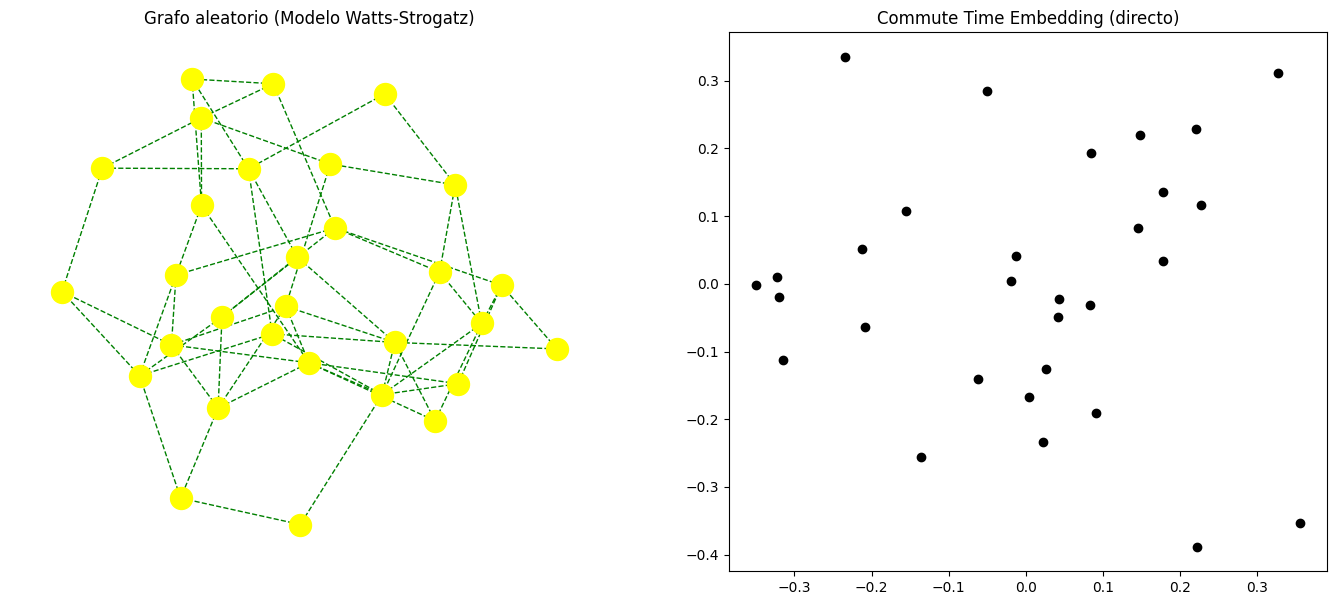

### **Información de los embeddings del grafo**

Embeddings shape: (30, 2)
Embeddings mean: -3.8857805861880476e-17
Embeddings max: 0.35588198257489795
Embeddings min: -0.38844668957057227


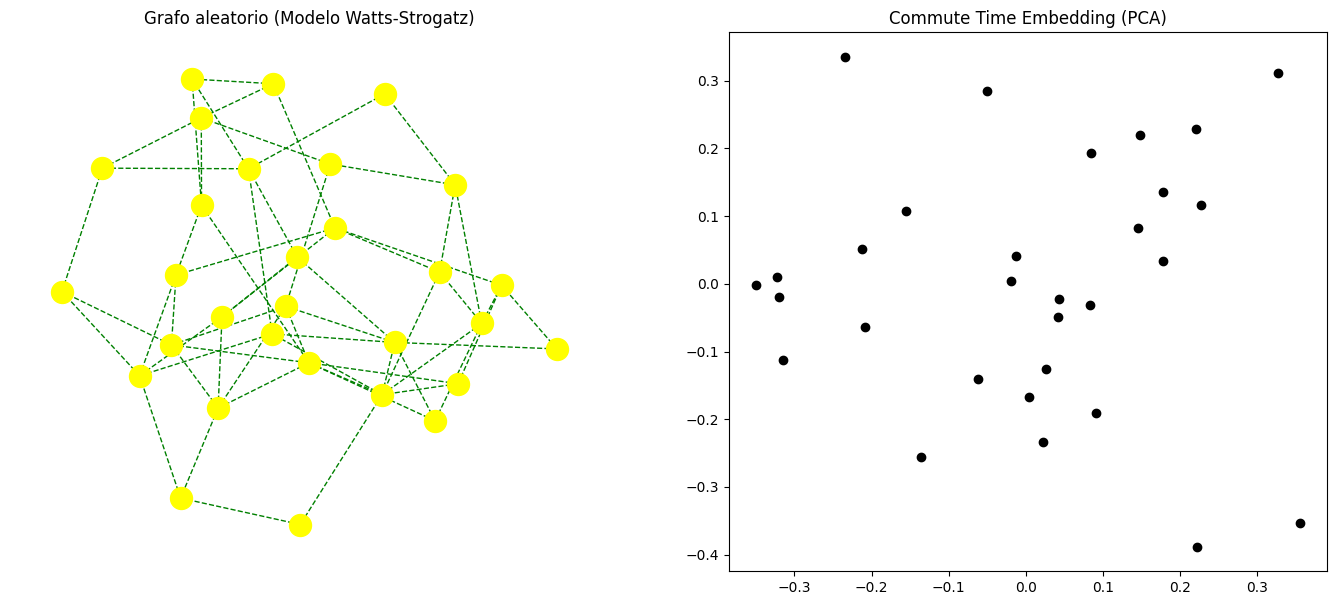

### **Información de los embeddings del grafo**

Embeddings shape: (30, 5)
Embeddings mean: -3.1086244689504386e-17
Embeddings max: 0.523201828617622
Embeddings min: -0.38844668957057266


In [38]:
visualization(g = "w_s", k=2)
visualization(g = "w_s", k=5)

**RANDOM TREE**

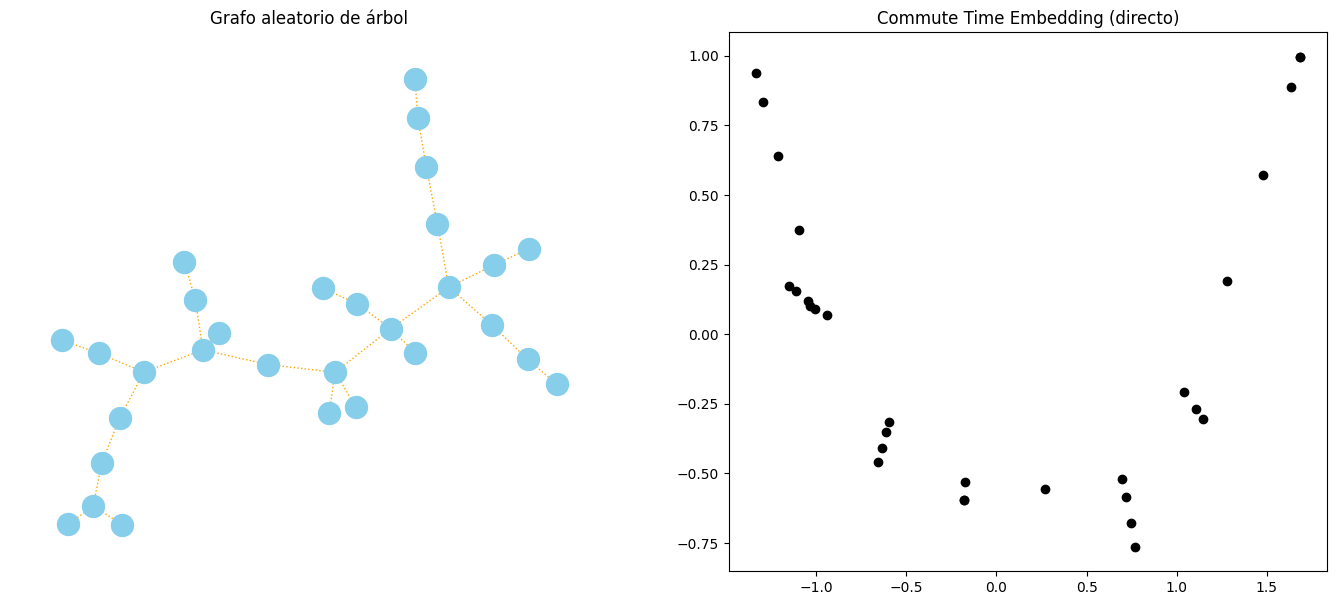

### **Información de los embeddings del grafo**

Embeddings shape: (30, 2)
Embeddings mean: 1.5450603759366761e-15
Embeddings max: 1.6852325253591312
Embeddings min: -1.3349070829259468


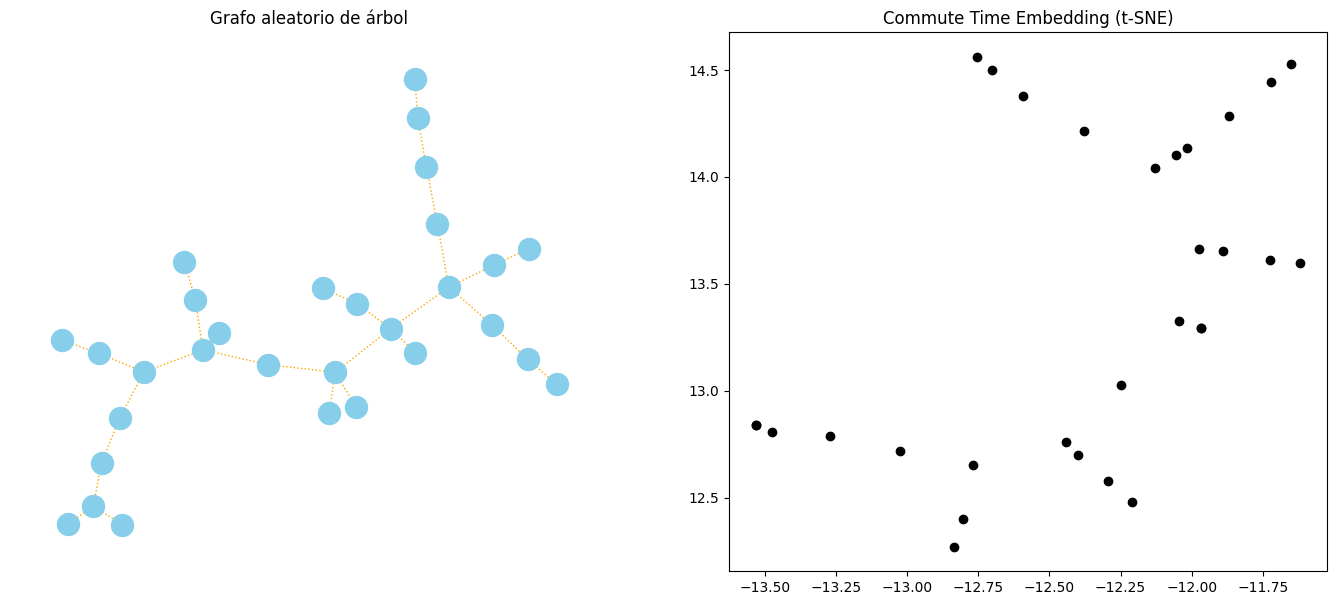

### **Información de los embeddings del grafo**

Embeddings shape: (30, 5)
Embeddings mean: 1.1131836193574904e-15
Embeddings max: 1.685232525359129
Embeddings min: -1.3349070829259435


In [39]:
visualization(g = "r_t", k=2)
visualization(g = "r_t", k=5)

**STOCHASTIC BLOCK MODEL**

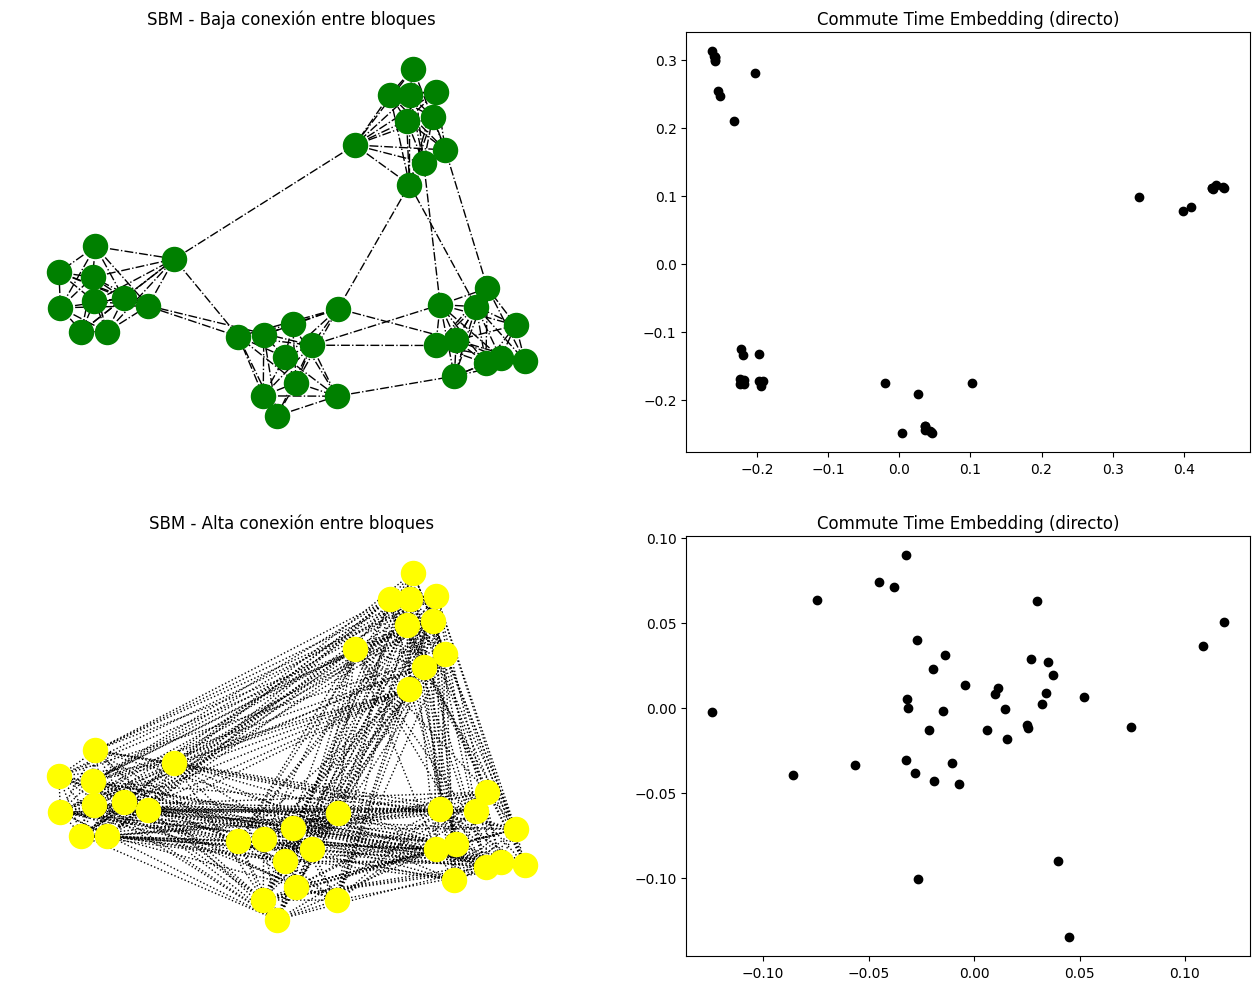

---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 2)
Embeddings mean: -1.27675647831893e-16
Embeddings max: 0.4573116028995419
Embeddings min: -0.26374691286237784


---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 2)
Embeddings mean: 6.938893903907229e-19
Embeddings max: 0.11866559921771891
Embeddings min: -0.13515997725406367


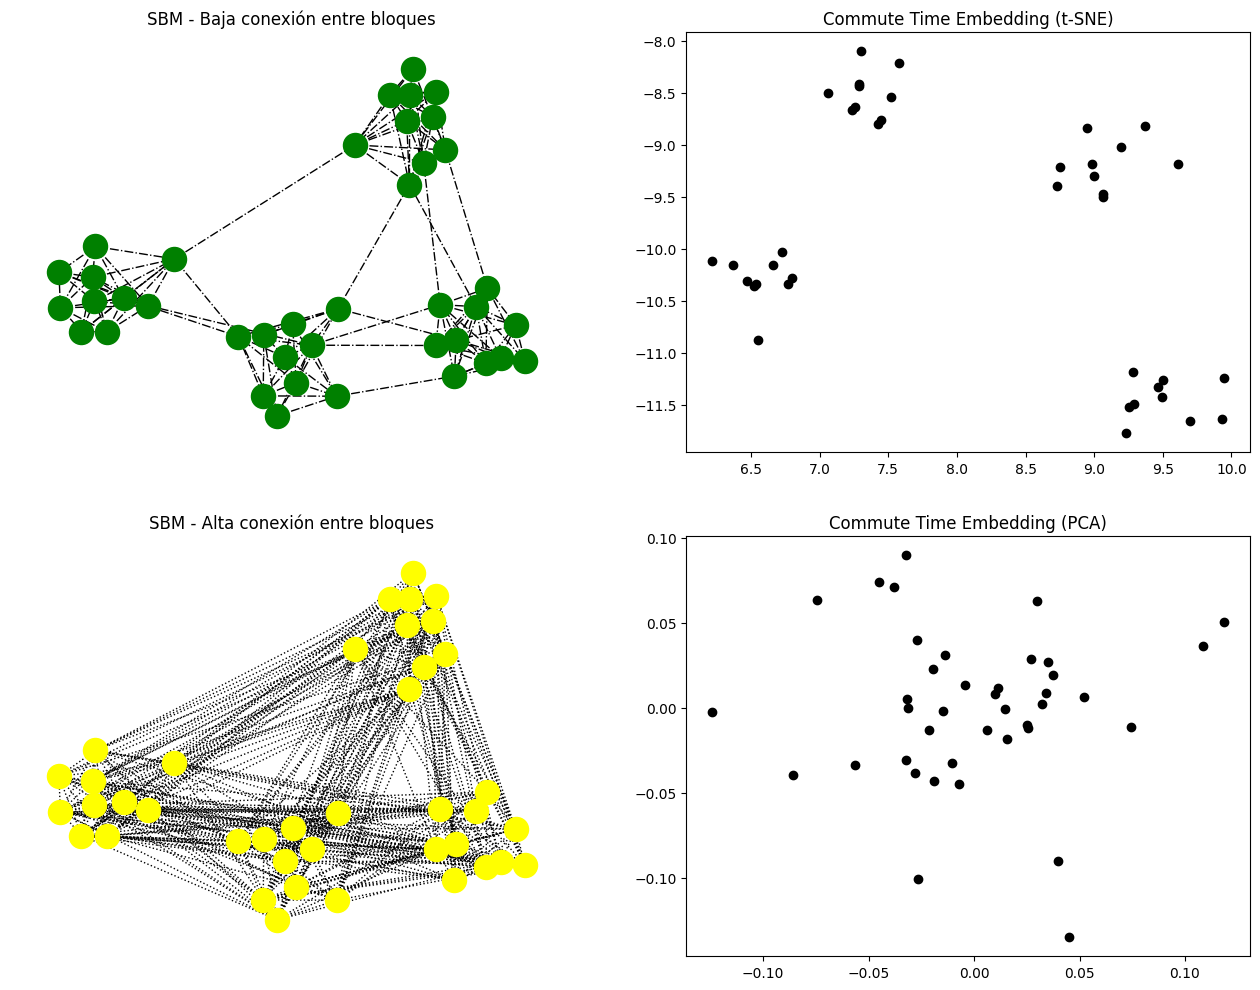

---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 10)
Embeddings mean: -1.8735013540549518e-18
Embeddings max: 0.4573116028995427
Embeddings min: -0.2637469128623785


---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 10)
Embeddings mean: 1.6653345369377347e-18
Embeddings max: 0.1697199897163757
Embeddings min: -0.13515997725406376


In [45]:
visualization(g = "SMB", k=2)
visualization(g = "SMB", k=10)

# CLAUDE -> IGNORA A PARTIR DE AQUÍ...

# Resultados y conslusiones

##### **¿Qué puedes decir sobre las incrustaciones de los nodos en el grafo?**
Los embeddings obtenidos representan cada nodo como un vector de 20 dimensiones que resume su papel (a nivel de estructura ...) dentro del grafo, el cual ha sido aprendido a partir de los random walks. Después de ver los resultados obtenidos, lo más a destacar es que  al observar los resultados de los 6 grafos, vemos como la forma de las embeddings reflejan las propiedades y caracterísiticas de cada modelo de grafos:

- En Erdos-Rényi y Barabási-Albert, las incrustaciones están distribuidas de forma desordenada, sin ningún patrón visible. Esto ocurre debido a que estos modelos de grafos no cuentan con ninguna estructura en comunidades ni nada por el estilo
- En Watts-Strogatz, la distribución es más extendida, reflejando la tensión entre clusterización local y los atajos del modelo de pequeño mundo.
- En el árbol, las incrustaciones muestran cierta separación en zonas. Esto captura la estructura jerárquica de ramas.
- En el SBM de baja conexión, las incrustaciones forman cuatro zonas claramente separadas, una por comunidad (caracterísitca clara del modelo SBM con baja conexión entre comunidades distintas)
- En el SBM de alta conexión, todas las incrustaciones colapsan en una nube compacta y casi indistinguible. Ocurre porque los bloques están tan interconectados que todos los nodos ven vecinos similares

En definitiva, podemos concluir que las incrustaciones no son arbitrarias puesto que se han visto reflejadas las caracterísitcas de los distintos modelos. Luego concluimos que los embeddings codifican la estructura real del grafo (si la estructura existe)

##### **¿Los nodos que están cerca en el grafo también están cerca en el espacio de incrustaciones?** 
Normalmente suele ser así, pero viene definido con matices según el tipo de grafo sobre el que estemos hablando:

- Erdos-Rényi: La proximidad en el grafo no se refleja bien en los embeddings. Al ser un grafo aleatorio sin estructura, los random walks mezclan todos los nodos por igual y no hay proximidad significativa que capturar

- Barabási-Albert: Ocurre parcialmente. Los nodos que comparten los mismos hubs (originales) tienden a aparecer en zonas similares, pero la nube sigue siendo difusa porque no hay comunidades definidas

- Watts-Strogatz: Parcialmente. La clusterización local se traduce en algo de agrupación, pero los atajos del modelo hacen que nodos que no son vecinos directos también aparezcan próximos en el embedding

- Árbol: En mayor medida que los anteriores. Al no haber ciclos, los random walks quedan "atrapados" en la misma subrama, por lo que nodos de la misma rama acaban con representaciones parecidas

- SBM baja conexión: Sí claramente. Es el caso donde esta propiedad se cumple mejor: los nodos de cada comunidad comparten casi todos sus vecinos y sus embeddings se agrupan visiblemente en cuatro zonas separadas

- SBM alta conexión: No. Con tanta conexión entre bloques, los random walks cruzan constantemente de una comunidad a otra y todos los nodos acaban con embeddings muy similares, independientemente de su posición en el grafo

##### **¿Qué puedes decir sobre la calidad de las incrustaciones?**

La calidad varía mucho entre grafos y es directamente proporcional a la claridad de la estructura del grafo:

- SBM baja conexión → calidad alta. Es el resultado más limpio: cuatro grupos perfectamente diferenciados en el scatter plot. Node2Vec ha identificado las comunidades sal 100%

- Árbol → calidad media-alta. La estructura jerárquica se captura bien, con zonas diferenciadas en el embedding, aunque no tan notables como en el SBM

- Watts-Strogatz → calidad media. Se captura algo de la estructura local, pero los atajos difuminan los grupos

- Barabási-Albert → calidad media-baja. Se aprecia algo más de varianza que en Erdos-Rényi, luego nos damos cuenta que node2vec recoge algo de la heterogeneidad de grados, pero sin separación clara

- Erdős-Rényi → calidad baja. Nube dispersa sin ningún patrón. Si el grafo no tiene estructura, Node2Vec no ha podido aprender mucho

- SBM alta conexión → calidad muy baja para detectar comunidades. Todos los embeddings colapsan en una nube compacta con valores mínimos (rango ±0.2), lo opuesto al SBM de baja conexión. Es el resultado más coherente con la teoría: cuando los bloques están muy interconectados, la estructura comunitaria desaparece desde el punto de vista de los random walks

##### **Y si pudieras mejorar la calidad de las incrustaciones, ¿cómo lo harías?**

Para mejorar la calidad de los embeddings de Node2Vec hay varios parámetros del algoritmo que podemos ajustar:

- **dimensions**: el tamaño del vector que representa cada nodo. Con valores más altos el modelo tiene más capacidad para capturar información, pero con grafos pequeños (como los nuestros de 30-40 nodos) tampoco hace falta aumentar mucho este valor (con 64 o 128 ya se nota mejora respecto a 20)

- **num_walks**: cuántos caminos aleatorios se generan por nodo. Cuantos más caminos, más "ejemplos" ve el modelo de cada nodo y mejor aprende su posición en el grafo. El coste es que tarda más en entrenar

- **walk_length**: la longitud de cada camino. Caminos más cortos capturan solo el vecindario inmediato (estructura local), caminos más largos permiten al modelo ver más lejos y capturar estructura global. Para grafos con comunidades bien definidas, caminos largos ayudan mucho

Para lograr una mejora en la calidad de los embeddings, vamos a cambiar los parámetros recién explicados y vamos a visualizar nuevamente los embeddings tanto con los parámetros por defecto como con los optimizados y comentar las posibles diferencias notables. Para lograr esto, vamos a modificar las funciones anteriores permitiendo pasar como parámetros dichos argumentos:

In [ ]:
# FUNCIÓN NODE2VEC + EMBEDDINGS
def n2v(g, dimensions=20, num_walks=15, walk_length=90, reduction='pca'):
    """
    Función que aplica node2vec al grafo g y reduce los embeddings a 2D para poder visualizarlos.
    Los parámetros del algoritmo se pueden ajustar para mejorar la calidad de los embeddings:
        - dimensions : cuantos más, más información captura cada nodo (pero más lento)
        - num_walks  : cuantos más caminos, mejor aprende el modelo (pero más lento)
        - walk_length: caminos más largos capturan contexto más global del grafo
        - reduction  : 'pca' es más rápido, 'tsne' suele separar mejor los grupos

    Args
    -----
        - g          : Grafo sobre el que aplicar node2vec
        - dimensions : Dimensión de los embeddings (tamaño del vector de cada nodo)
        - num_walks  : Número de caminos aleatorios por nodo
        - walk_length: Longitud de cada camino aleatorio
        - reduction  : Técnica de reducción a usar ('pca' o 'tsne')

    Returns
    -------
        - embeddings_2d: Embeddings reducidos a 2 dimensiones
        - name         : Nombre de la técnica de reducción usada
        - embeddings   : Embeddings originales (alta dimensión)
    """
    model = node2vec(g, dimensions=dimensions, num_walks=num_walks, walk_length=walk_length)
    embeddings = np.array([model.wv[str(node)] for node in g.nodes()])  # embeddings

    # APLICAMOS REDUCCIÓN A LOS EMBEDDINGS OBTENIDOS
    if reduction == 'pca':
        embeddings_2d, name = pca(embeddings)
    else:
        embeddings_2d, name = t_sne(embeddings)

    return embeddings_2d, name, embeddings


# FUNCIÓN DE VISUALIZACIÓN
def visualization(g, dimensions=20, num_walks=15, walk_length=90, reduction='pca') -> None:  # Valores por defecto (como argumentos para posibles cambios)
    """
    Esta función muestra de forma visual un grafo y sus embeddings después de aplicar node2vec. El objetivo es mostrar en una figura 
    dos visualizaciones: en la primera mostramos el grafo original y en la segunda los embeddings del mismo. Además, debajo de imprimen
    por pantalla los datos obtenidos despues de aplicar node2vec al grafo. Para mostrar las visualizaciones, se utiliza o PCA o t-SNE,
    que se puede especificar con el parámetro reduction (por defecto PCA)

    Args
    -----
        - g          : Tipo de grafo sobre el que queremos aplicar el algoritmo node2vec
        - dimensions : Dimensión de los embeddings (tamaño del vector de cada nodo)
        - num_walks  : Número de caminos aleatorios por nodo
        - walk_length: Longitud de cada camino aleatorio
        - reduction  : Técnica de reducción a usar ('pca' o 'tsne')

    """

    # Construimos los casos según el tipo de grafo (ya que usamos los grafos creados en la práctica anterior)

    # ERDOS-RÉNYI
    if g == "e_r":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        e_r = nx.erdos_renyi_graph(30, 0.25, seed = 50)   # 30 nodos | Probabilidad de arista del 25%
        ax[0].set_title('Grafo aleatorio (Modelo Erdos-Rényi)')
        posiciones = nx.spring_layout(e_r, seed = 18)
        nx.draw_networkx_nodes(e_r, posiciones, node_color = 'black', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(e_r, posiciones, edge_color = 'red', style = '-.', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo con los parámetros que nos pasen
        embeddings_2d, method, embeddings = n2v(e_r, dimensions, num_walks, walk_length, reduction)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # BRABÁSI-ALBERT
    if g == "b_a":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        b_a = nx.barabasi_albert_graph(30, 4, seed = 50)   # 30 nodos | Nº enlaces por nodo: 4
        ax[0].set_title('Grafo aleatorio (Modelo Barbási-Albert)')
        posiciones = nx.spring_layout(b_a, seed = 18)
        nx.draw_networkx_nodes(b_a, posiciones, node_color = 'red', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(b_a, posiciones, edge_color = 'black', style = '--', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo con los parámetros que nos pasen
        embeddings_2d, method, embeddings = n2v(b_a, dimensions, num_walks, walk_length, reduction)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # WATTS-STROGATZ
    if g == "w_s":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        w_s = nx.watts_strogatz_graph(30, 4, 0.5, seed = 50)   # 30 nodos | Grado medio: 4 | Probabilidad reconexión: 0.5
        ax[0].set_title('Grafo aleatorio (Modelo Watts-Strogatz)')
        posiciones = nx.spring_layout(w_s, seed = 18)
        nx.draw_networkx_nodes(w_s, posiciones, node_color = 'yellow', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(w_s, posiciones, edge_color = 'green', style = '--', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo con los parámetros que nos pasen
        embeddings_2d, method, embeddings = n2v(w_s, dimensions, num_walks, walk_length, reduction)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # ÁRBOL
    if g == "r_t":

        # Visualizamos grafo sintético
        fig, ax = plt.subplots(1,2, figsize=(17,7))
        r_t = nx.random_labeled_tree(30, seed = 50)   # 30 nodos 
        ax[0].set_title('Grafo aleatorio de árbol')
        posiciones = nx.spring_layout(r_t, seed = 18)
        nx.draw_networkx_nodes(r_t, posiciones, node_color = 'skyblue', node_size = 250, ax=ax[0])
        nx.draw_networkx_edges(r_t, posiciones, edge_color = 'orange', style = ':', ax=ax[0])
        ax[0].axis('off')

        # Aplicamos algoritmo y reducción al grafo con los parámetros que nos pasen
        embeddings_2d, method, embeddings = n2v(r_t, dimensions, num_walks, walk_length, reduction)

        # Visualizamos embeddins
        ax[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='black')       
        ax[1].set_title(f'Node2Vec embeddings ({method})')
        plt.show()

        properties(embeddings)

    # SMB

    """
    Para este caso, vamos a realizar 4 subplots. En el lado izquierdo vamos a tener los dos grafos sintétcicos SBM,
    teniendo el grafo de baja conexión (entre comunidades) arriba y el grafo de alta conexión (entre comunidades) abajo.
    A la derecha tendremos los embeddings tanto como para SBM - baja conexión como con el SBM - alta conexión
    
    """
    if g == "SMB":
        sizes = [10, 10, 10, 10]
        baja = [[0.8, 0.02, 0.02, 0.02],[0.02, 0.8, 0.02, 0.02],[0.02, 0.02, 0.8, 0.02],[0.02, 0.02, 0.02, 0.8]]
        alta = [[0.8, 0.4, 0.4, 0.4],[0.4, 0.8, 0.4, 0.4],[0.4, 0.4, 0.8, 0.4],[0.4, 0.4, 0.4, 0.8]]
        seed = 96

        # Creamos grafos SBM
        G1 = nx.stochastic_block_model(sizes, baja, seed=seed)
        G2 = nx.stochastic_block_model(sizes, alta, seed=seed)

        # Aplicamos Node2Vec + reducción con los parámetros que nos pasen
        emb_baja, method_baja, embeddings_baja = n2v(G1, dimensions, num_walks, walk_length, reduction)
        emb_alta, method_alta, embeddings_alta = n2v(G2, dimensions, num_walks, walk_length, reduction)

        # Creamos figura 2x2
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Posiciones
        pos = nx.spring_layout(G1, seed=seed)

        # Baja conexión
        axes[0,0].set_title('SBM - Baja conexión entre bloques')
        nx.draw_networkx_nodes(G1, pos,node_size=300,node_color='green',ax=axes[0,0])
        nx.draw_networkx_edges(G1,pos,edge_color='black',style='-.',ax=axes[0,0])
        axes[0,0].axis('off')

        # Visualizamos embeddins
        axes[0,1].scatter(emb_baja[:,0],emb_baja[:,1],color='black')
        axes[0,1].set_title(f'Embeddings SBM ({method_baja})')

        # Alta conexion
        axes[1,0].set_title('SBM - Alta conexión entre bloques')

        nx.draw_networkx_nodes(G2,pos,node_size=300,node_color='yellow',ax=axes[1,0])
        nx.draw_networkx_edges(G2,pos,edge_color='black',style=':',ax=axes[1,0]
)
        # Visualizamos embeddins
        axes[1,0].axis('off')
        axes[1,1].scatter( emb_alta[:,0],emb_alta[:,1],color='black')
        axes[1,1].set_title(f'Embeddings SBM ({method_alta})')

        plt.show()

        display(Markdown('---'))
        properties(embeddings_baja)
        display(Markdown('---'))
        properties(embeddings_alta)

### Optimización

Ahora que hemos diseñado las funciones para ajustar los parámetros de `node2vec`, vamos a comparar la calidad de los embbeddings con los valores originiales y luego ajustando los parámetros (objetivo es mejorar calidad) para cada uno de los grafos sintéticos usados anteriormente (4 + 2)

Recordatorio de los valores originales:
```bash
- dimensions = 20
- num_walks = 15
- walk_lenght = 90
- reduction = 'pca'
```



##### **ERDOS-RÉNYI**

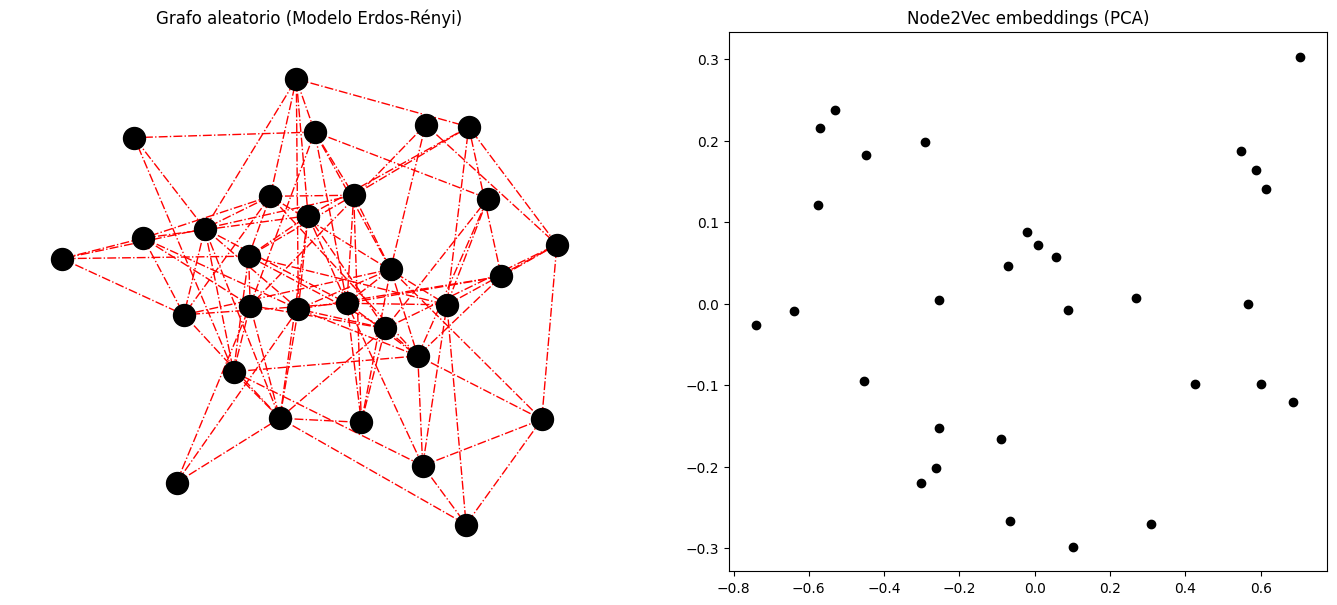

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.034052684903144836
Embeddings max: 0.8322095274925232
Embeddings min: -0.6061204075813293


---
**OPTIMIZACIÓN PARÁMETROS**
---

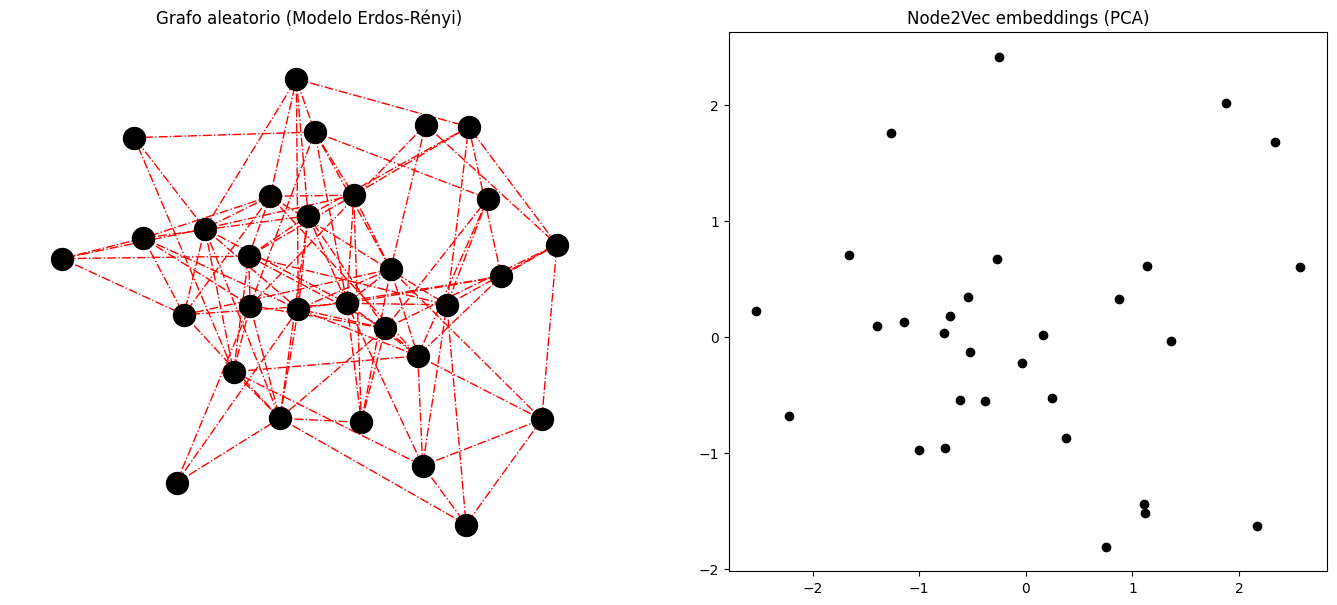

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.02915116585791111
Embeddings max: 1.7352396249771118
Embeddings min: -2.3273041248321533


In [ ]:
# ERDOS-RÉNYI
visualization("e_r")
display(Markdown(f'---\n**OPTIMIZACIÓN PARÁMETROS**\n---'))

# El grafo Erdos-Rényi no tiene estructura clara, así que subimos num_walks y walk_length
# para que el modelo vea más contexto de cada nodo y pueda capturar aunque sea las 
# pequeñas diferencias de conexiones que hay entre nodos

num_walks = 50
walk_lenght = 200

visualization("e_r", num_walks=num_walks, walk_length=walk_lenght)

Al aplicar Node2Vec al grafo de Erdős-Rényi con los parámetros base (num_walks=15, walk_length=90), los embeddings proyectados mediante PCA forman una nube dispersa sin ningún patrón visible, con valores comprendidos en un rango de aproximadamente +- 1.5. Tras incrementar el número de caminos a 50 y la longitud a 200, la distribución sigue siendo difusa pero se extiende ligeramente (+- 2.5), sin que aparezcan agrupaciones. Este resultado es coherente con la naturaleza del modelo puesto que al no existir estructura comunitaria ni roles diferenciados en el grafo, Node2Vec no tiene nada que aprender y el aumento de parámetros solo incrementa la varianza de los embeddings sin producir una separación notable

##### **BARABÁSI-ALBERT**

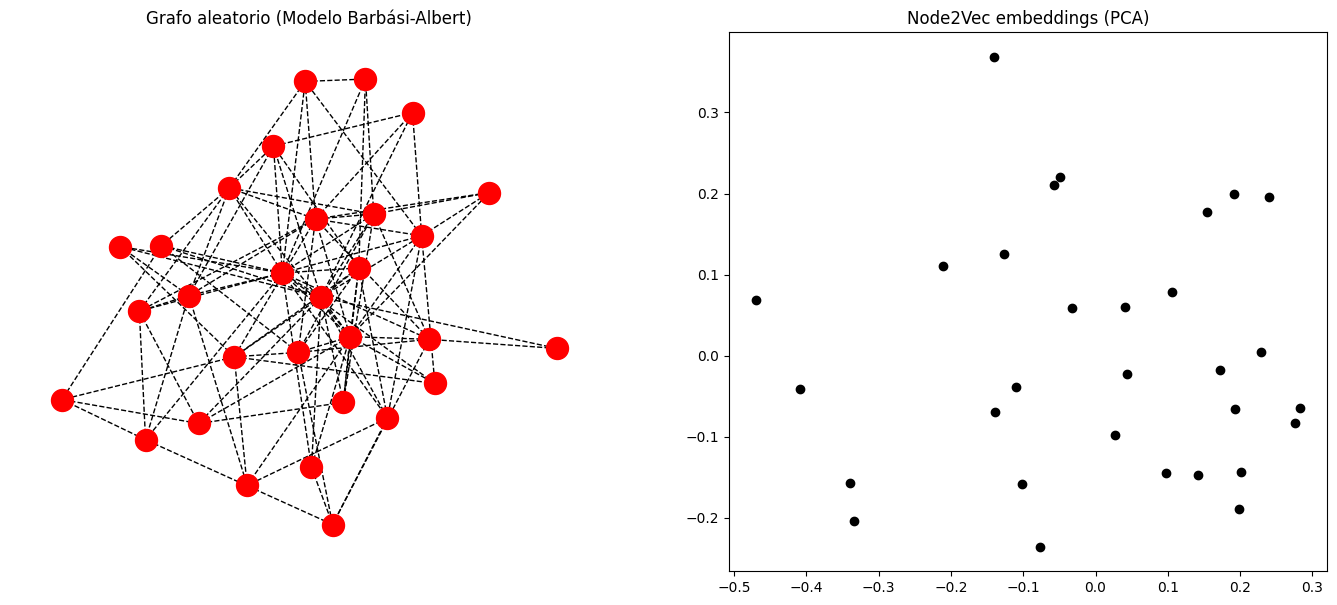

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.040437038987874985
Embeddings max: 0.7866019606590271
Embeddings min: -0.6641685366630554


---
**OPTIMIZACIÓN PARÁMETROS**
---

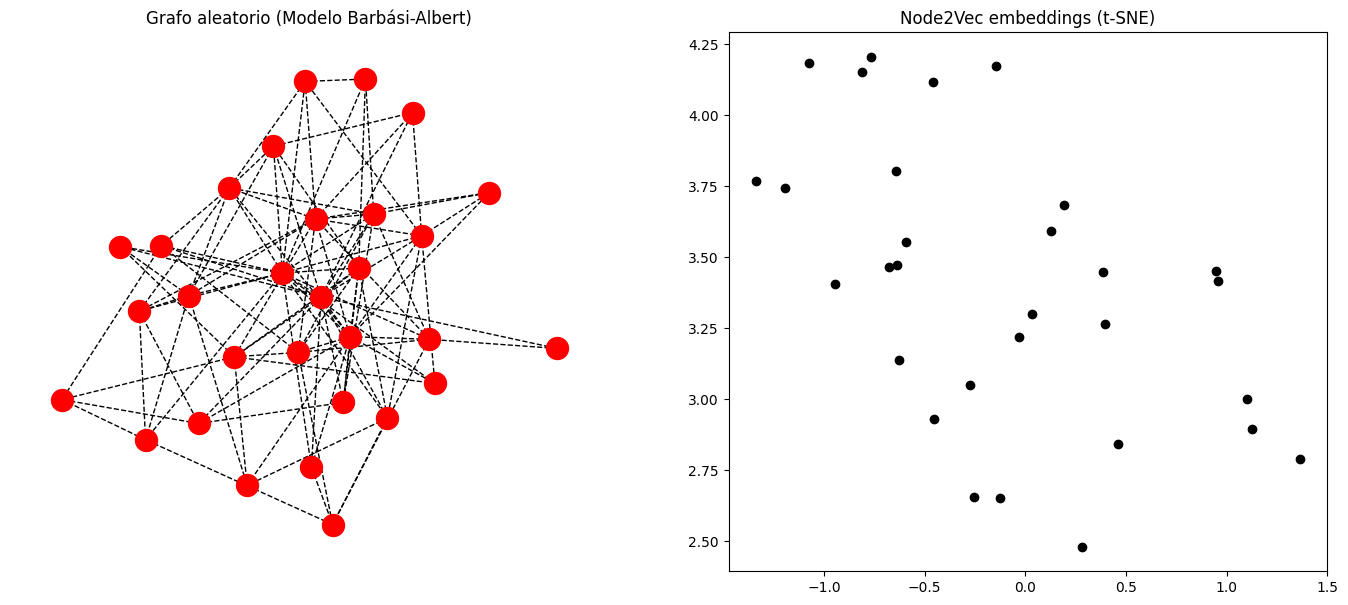

### **Información de los embeddings del grafo**

Embeddings shape: (30, 64)
Embeddings mean: 0.028317177668213844
Embeddings max: 0.56419438123703
Embeddings min: -0.4696846008300781


In [ ]:
# BARABÁSI-ALBERT
visualization("b_a")
display(Markdown(f'---\n**OPTIMIZACIÓN PARÁMETROS**\n---'))

# En Barabási-Albert hay hubs muy conectados y nodos periféricos con pocas conexiones.
# Subimos dimensions para que el modelo tenga más capacidad de diferenciar estos roles,
# y usamos t-SNE porque separa mejor grupos con densidades tan distintas

dimensions = 64
reduction = 'tsne'

visualization("b_a", dimensions=dimensions, reduction=reduction)

En el grafo de Barabási-Albert, los embeddings base con PCA presentan una nube compacta y sin estructura aparente, con un rango de valores muy reducido (+-0.35). Al aumentar la dimensionalidad a 64 y visualizar con t-SNE, el scatter plot muestra una mayor dispersión de los puntos y una cierta separación emergente. Esta mejora se debe a dos factores combinados: por un lado, dimensiones más altas permiten al modelo capturar mejor la heterogeneidad de roles (nodos hub frente a nodos periféricos); por otro lado, t-SNE, al preservar las relaciones de vecindad local en lugar de buscar direcciones de máxima varianza global, es capaz de revelar agrupaciones sutiles que PCA aplana. Aun así, la separación no es tan nítida como en los grafos con comunidades bien definidas, lo que refleja que la estructura de Barabási-Albert es de naturaleza jerárquica y continua, no discreta

##### **WATTS-STROGATZ**

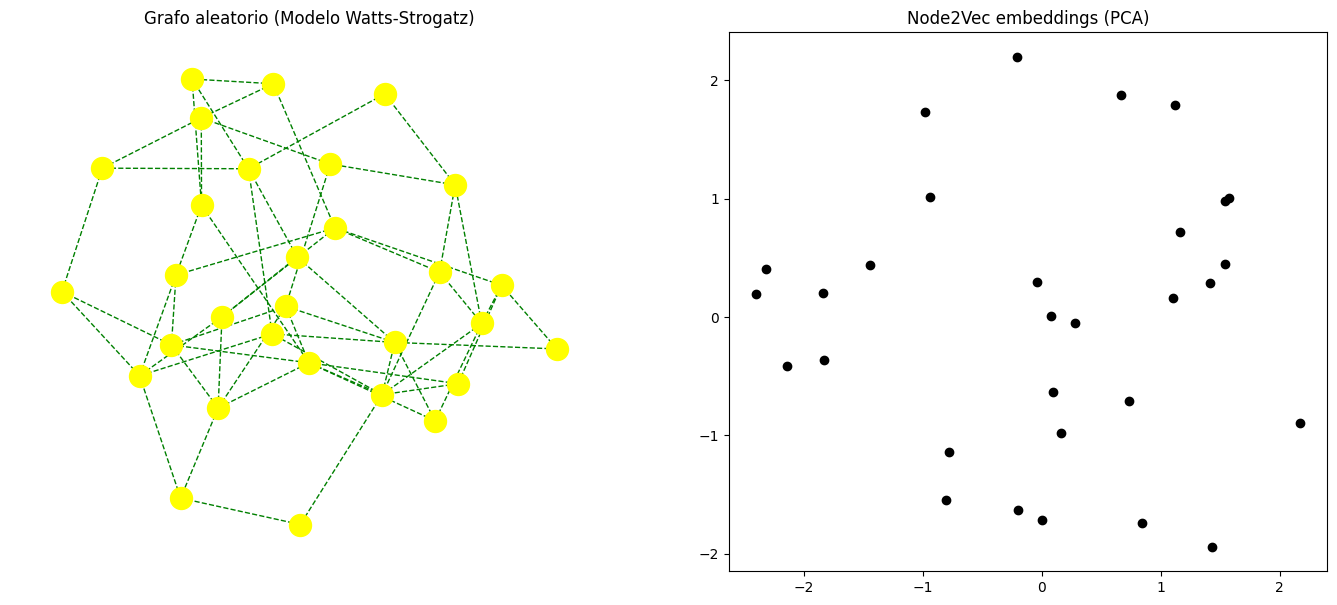

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.040033113211393356
Embeddings max: 1.710753321647644
Embeddings min: -1.5039844512939453


---
**OPTIMIZACIÓN PARÁMETROS**
---

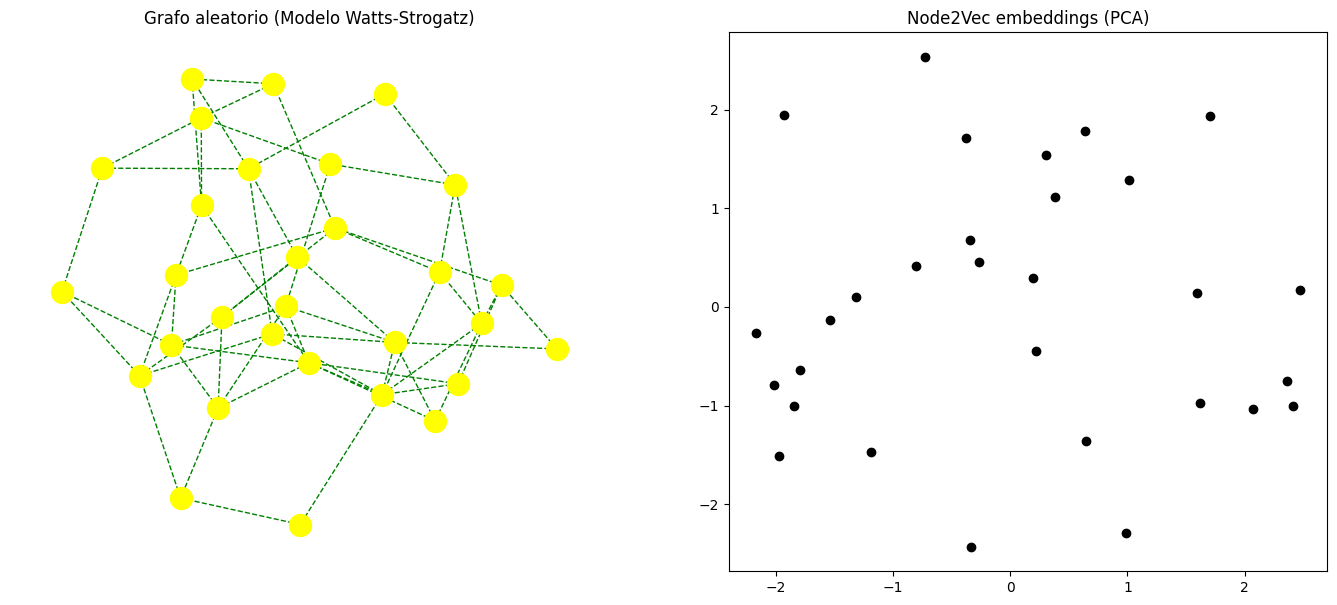

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.01734105683863163
Embeddings max: 1.8871383666992188
Embeddings min: -2.1637818813323975


In [ ]:
# WATTS-STROGATZ
visualization("w_s")
display(Markdown(f'---\n**OPTIMIZACIÓN PARÁMETROS**\n---'))

# Watts-Strogatz tiene clusterización local pero con atajos que conectan nodos lejanos.
# Aumentamos walk_length para que los caminos puedan capturar tanto la estructura local
# como esos atajos, y así los embeddings reflejan mejor el balance entre ambas cosas

walk_length = 200

visualization("w_s", walk_length=walk_length)

El grafo de Watts-Strogatz, generado con probabilidad de reconexión p=0.5, produce embeddings base dispersos y sin agrupaciones visibles al visualizarlos con PCA. Al aumentar la longitud de los caminos a 200, la distribución se amplía ligeramente pero mantiene el mismo aspecto difuso. La escasa mejora se explica por la alta tasa de reconexión del modelo: con p=0.5 el grafo contiene numerosos atajos que rompen la clusterización local, haciendo que los random walks largos lleguen a cualquier zona del grafo con facilidad y no encuentren vecindarios diferenciados. Si la probabilidad de reconexión fuera baja (p =(+-)0.05), un mayor walk_length sería muy beneficioso para capturar la estructura anular original; pero con p=0.5 el grafo se asemeja demasiado a un aleatorio para que esta técnica aporte separación clara

##### **RANDOM TREE**

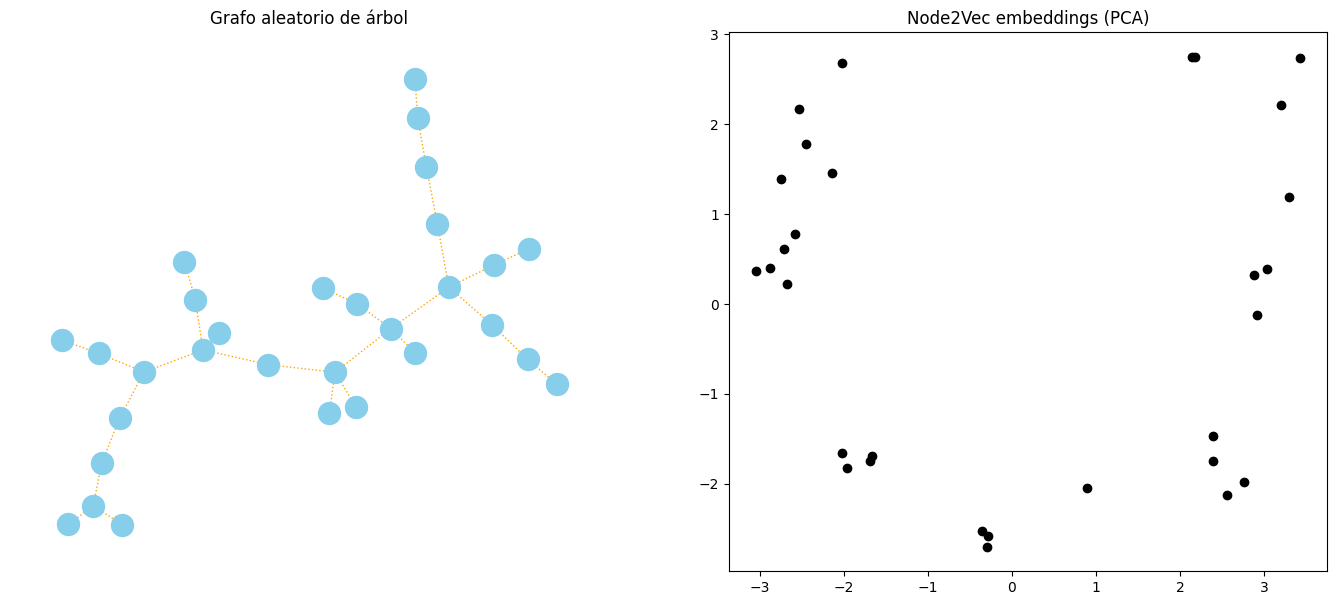

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: 0.024168482050299644
Embeddings max: 2.5378687381744385
Embeddings min: -2.2976555824279785


---
**OPTIMIZACIÓN PARÁMETROS**
---

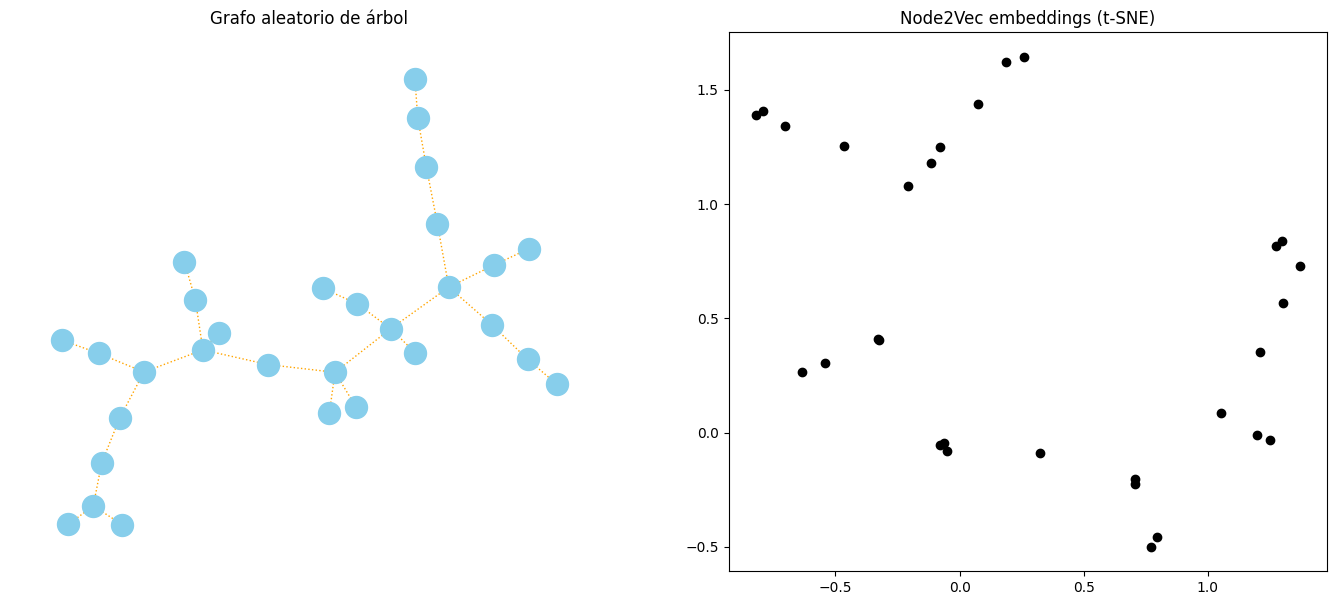

### **Información de los embeddings del grafo**

Embeddings shape: (30, 20)
Embeddings mean: -0.017207063734531403
Embeddings max: 3.6479883193969727
Embeddings min: -4.442822456359863


In [ ]:
# ÁRBOL
visualization("r_t")
display(Markdown(f'---\n**OPTIMIZACIÓN PARÁMETROS**\n---'))

# En un árbol no hay ciclos, así que los caminos aleatorios se quedan atrapados en ramas.
# Subimos num_walks para compensar esto (más caminos desde cada nodo = más variedad)
# y usamos t-SNE porque separa mejor la estructura jerárquica visualmente

num_walks = 50
reduction = 'tsne'

visualization("r_t", num_walks=num_walks, reduction=reduction)

En el árbol aleatorio, los embeddings base visualizados con PCA ya sugieren cierta separación en zonas (entre 3 y 4 regiones), aunque con bastante dispersión interna. Al incrementar el número de caminos a 50 y cambiar la visualización a t-SNE, los grupos se vuelven notablemente más compactos y diferenciados. La mejora se debe a que en un árbol la ausencia de ciclos confina los random walks a las ramas, por lo que más caminos equivale a mayor cobertura estadística y embeddings más estables por nodo. t-SNE contribuye adicionalmente porque, al preservar las relaciones de vecindad local, es capaz de resaltar la estructura jerárquica del árbol mejor que PCA, que solo captura la dirección de máxima varianza global y puede mezclar ramas que en el espacio original están bien separadas

##### **SMB**

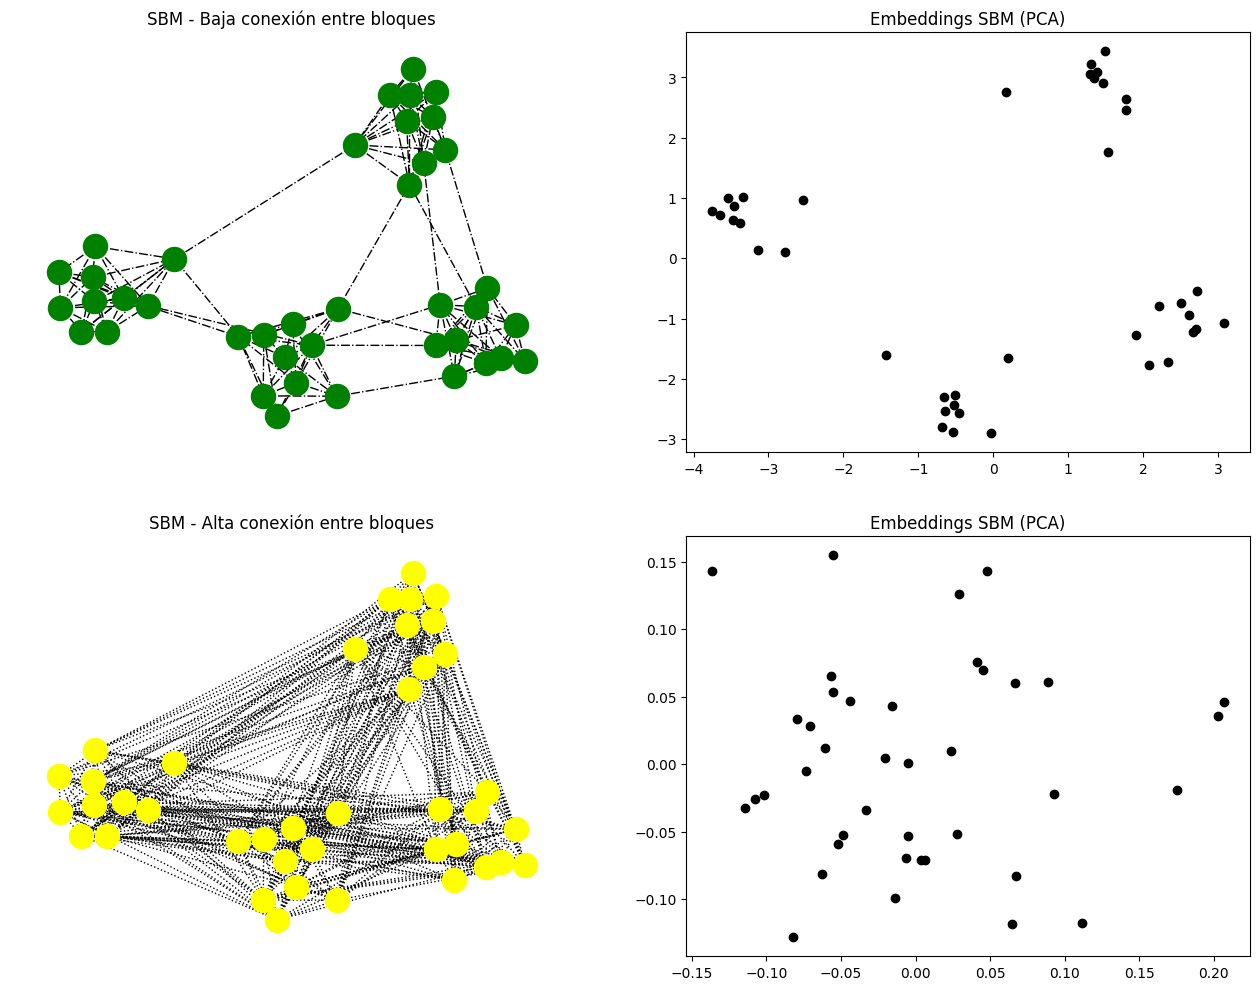

---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 20)
Embeddings mean: -0.0201939158141613
Embeddings max: 2.09932279586792
Embeddings min: -2.255525588989258


---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 20)
Embeddings mean: -0.02628866583108902
Embeddings max: 0.6208648681640625
Embeddings min: -0.6855122447013855


---
**OPTIMIZACIÓN PARÁMETROS**
---

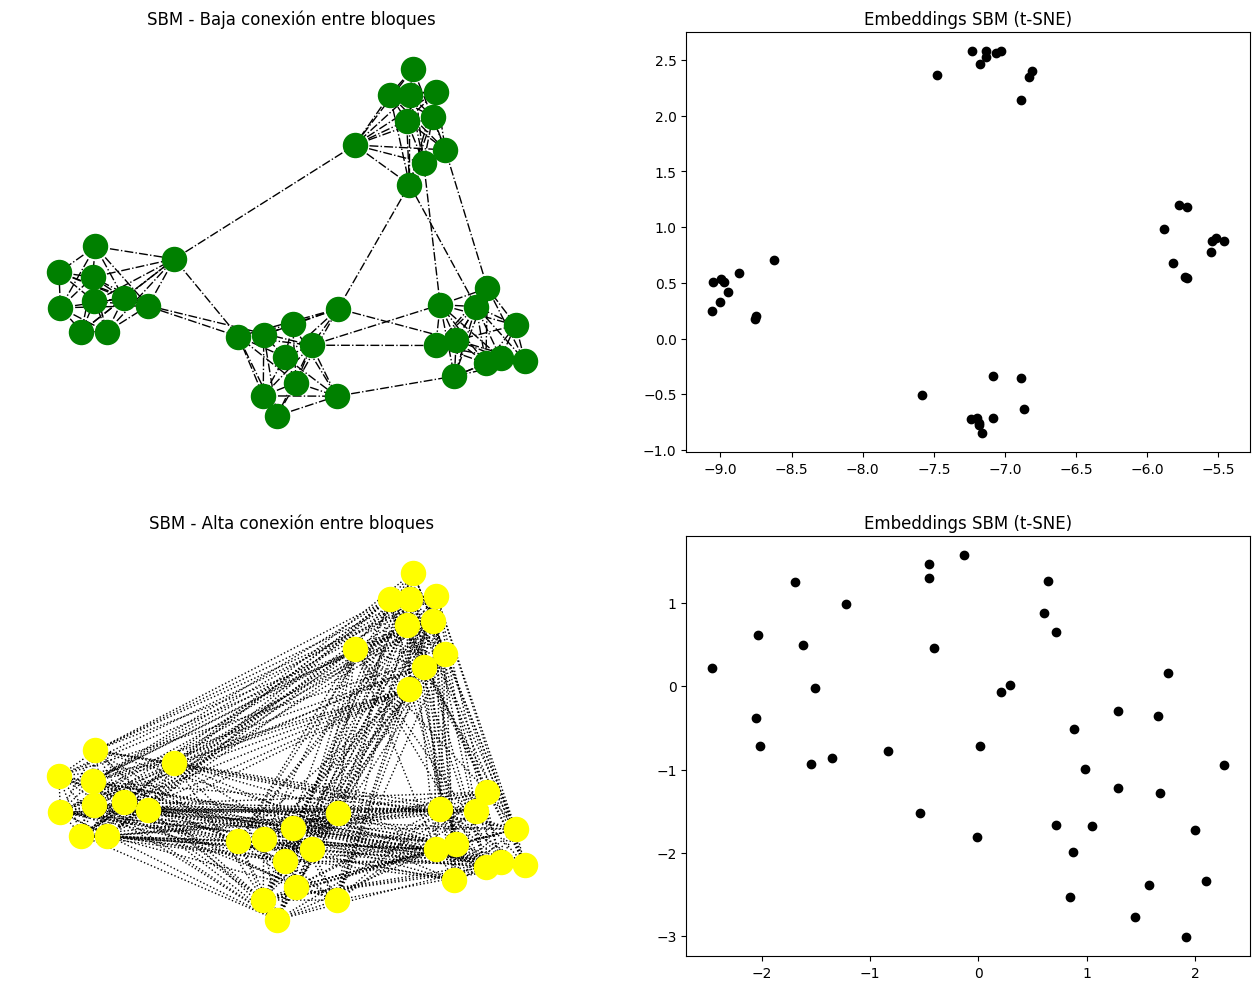

---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 64)
Embeddings mean: 0.025028372183442116
Embeddings max: 1.500690221786499
Embeddings min: -1.5640051364898682


---

### **Información de los embeddings del grafo**

Embeddings shape: (40, 64)
Embeddings mean: 0.02943086065351963
Embeddings max: 0.43645137548446655
Embeddings min: -0.5075802803039551


In [ ]:
# SBM
visualization("SMB")
display(Markdown(f'---\n**OPTIMIZACIÓN PARÁMETROS**\n---'))

# Para el SBM de baja conexión, con walk_length más largo y más dimensions le damos al 
# modelo más capacidad para separar aún mejor las 4 comunidades.
# Para el SBM de alta conexión el problema es la propia estructura del grafo (demasiada
# conexión entre bloques), así que la mejora de parámetros ayuda poco. Aun así usamos 
# t-SNE porque intenta separar mejor los puntos aunque estén muy juntos

dimensions = 64
walk_length = 200
reduction = 'tsne'

visualization("SMB", dimensions=dimensions, walk_length=walk_length, reduction=reduction)

**Baja conexión**: \
El SBM de baja conexión es el caso donde la optimización de parámetros produce el resultado más llamativo. Con los valores base y PCA ya se distinguían algunos agrupamientos, pero con 64 dimensiones, walk_length=200 y t-SNE los embeddings forman cuatro clústeres perfectamente delimitados, uno por comunidad. La explicación es que los tres cambios actúan de forma sinérgica sobre una estructura que ya existía: aumentar las dimensiones da al modelo más capacidad para codificar las diferencias entre bloques, caminos más largos profundizan la exploración dentro de cada comunidad al tiempo que los random walks rara vez cruzan al bloque vecino (probabilidad 0.02), y t-SNE es especialmente eficaz cuando los datos tienen agrupaciones discretas y bien separadas, que es exactamente el caso aquí. El resultado valida que Node2Vec es capaz de recuperar comunidades sin ningún tipo de etiqueta supervisada

**Alta conexión**: \
En el SBM de alta conexión, la optimización de parámetros no consigue revelar la estructura comunitaria porque dicha estructura ha desaparecido desde el punto de vista de los random walks. Con los valores base, los embeddings forman una nube muy compacta (rango +-0.2) que con t-SNE y 64 dimensiones se expande notablemente (rango hasta +- 3.6), pero sin mostrar ninguna agrupación discernible. La razón es que con una probabilidad de conexión entre bloques de 0.4, los random walks cruzan de comunidad en comunidad en prácticamente cada paso, haciendo que todos los nodos acumulen contextos similares independientemente de su bloque de origen. En estas condiciones, subir dimensiones, aumentar walk_length o usar t-SNE solo amplifica el ruido existente, no la señal, ya que la señal comunitaria es demasiado débil para que Node2Vec la capture. Es el resultado más instructivo de la práctica: los embeddings reflejan lo que hay en el grafo, y si el grafo no tiene estructura, los embeddings tampoco la tienen